# **Final Project Deep Learning for the Social Sciences:**
## **Education Investment Forecasting for Regional Economic Development**

---

## Project Description

This project uses Recurrent Neural Networks (RNNs) to analyze time-series data on education expenditures and predict regional economic outcomes 10–15 years ahead (changed to 3 Years due to limited  data availability). Students will investigate how foundational education investments drive long-term economic growth and workforce development.

---

## Part 1

### Data Collection
- Obtain K-12 education expenditure data (or similar) from NCES school finance surveys and teacher salary databases.
- Collect regional economic indicators from the Bureau of Economic Analysis (BEA) and employment statistics from the Bureau of Labor Statistics (BLS).

### Data Cleaning
- Standardize geographical units.
- Handle missing values.
- Align temporal sequences.
- Categorize expenditures and normalize economic indicators.

### Preliminary Data Analysis and Visualization
- Investigate long-term relationships between education spending and economic outcomes.
- Visualize trends and perform cross-regional comparisons using appropriate time-series plots.

---

## Part 2: Deep Learning Model (10 points)

### Build RNN Model
- Develop an LSTM (Long Short-Term Memory) or similar architecture using PyTorch for long-term predictions (10–15 year horizons).
- Use a multivariate time series model.
- Provide well-commented, reproducible code in a repository linked in the report.

### Model Training and Validation
- Train the model using historical education-economic outcome data with appropriate sequence lengths.
- Use temporal cross-validation and long-term prediction accuracy metrics for model validation.

### Deployment and Testing
- Apply the model to recent data to forecast future outcomes.
- Identify which categories of education expenditure most strongly correlate with economic growth.

---

In [ ]:
# Import neccesary libraries

#Basics
import pandas as pd
import numpy as np
from collections import Counter

#Basic Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pandas.plotting import autocorrelation_plot

#Autocorrelations and Stationarity
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller

#Map Vis
import geopandas as gpd
import requests, zipfile, io, os
import matplotlib.patches as mpatches

---
# Part 1

## Data Collection
- Obtain K-12 education expenditure data (or similar) from NCES school finance surveys and teacher salary databases.
- Collect regional economic indicators from the Bureau of Economic Analysis (BEA) and employment statistics from the Bureau of Labor Statistics (BLS).
---

In [ ]:
#import seperate datasets
NCES_Data = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/NCES_Data/NCES_cbsa.csv')
outcomes_Data = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Outcome_Data/msa_mic_outcome_comb.csv')
jobcreation_Data = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Jobs_Data/jobcreation_cbsa.csv')

---
## Data Cleaning
- Standardize geographical units.
- Handle missing values.
- Align temporal sequences.
- Categorize expenditures and normalize economic indicators.
---

In [ ]:
#initial cleaning
#convert school years (e.g., "1986-87") to the later year (e.g., 1987), so they align with calendar years in the other datasets
#later year is chosen since a higehr percentage of the school year is in this year

#split and only keep the second year
NCES_Data["year"] = NCES_Data["year"].astype(str).str.split("-").str[1]

#add either a 19 or 20 in front of the years to get correct year labels
NCES_Data["year"] = NCES_Data["year"].apply(lambda x: int("19" + x) if int(x) >= 50 else int("20" + x))

#remove irrelevant columns form outcomes data set
relevants = ["CBSA_code","CBSA_name","year","Population (persons)","Per capita personal income (dollars)","Unemployment Rate"]
outcomes_Data = outcomes_Data[relevants]

In [ ]:
# Check the time frames covered for both datasets
print("Time frame of NCES Data:")
print(NCES_Data["year"].min())
print(NCES_Data["year"].max())
print("\nTime frame of Economic Outcome Data:")
print(outcomes_Data["year"].min())
print(outcomes_Data["year"].max())
print("\nTime frame of Jobcreation Data:")
print(jobcreation_Data["year"].min())
print(jobcreation_Data["year"].max())

Time frame of NCES Data:
1987
2023

Time frame of Economic Outcome Data:
1969
2023

Time frame of Jobcreation Data:
1998
2022


### Merge of Datasets

In [ ]:
# Left join on NCES with job creation and outcomes datasets
#rename cbsa column in outcomes
outcomes_Data = outcomes_Data.rename(columns={"CBSA_code": "CBSA_Code"})

#merge datasets
cbsa_df_firstmerge = pd.merge(NCES_Data,outcomes_Data, on=["CBSA_Code", "year"], how="left")
cbsa_df = pd.merge(cbsa_df_firstmerge,jobcreation_Data, on=["CBSA_Code", "year"], how="left")

#remove double CBSA name
cbsa_df = cbsa_df.drop(columns=["CBSA_name_y"])

#rename CBSA name
cbsa_df = cbsa_df.rename(columns={"CBSA_name_x": "CBSA_Name"})

#rename the columns from the outcomes data frame
cbsa_df = cbsa_df.rename(columns={"Population (persons)": "population",
                                  "Per capita personal income (dollars)": "per_cap_income",
                                  "Unemployment Rate": "unemployment"})

In [ ]:
#extract main state form cbsa name (first state is always the main one if there are multiple)
cbsa_df['main_state'] = cbsa_df['CBSA_Name'].str.extract(r',\s*([A-Z]{2})')

#move column to index 2 for cleaner data frame
cbsa_df.insert(2, 'main_state', cbsa_df.pop('main_state'))

In [ ]:
#create a column for the main state of each CBSA
cbsa_df['main_state'] = cbsa_df['CBSA_Name'].str.extract(r',\s*(.*)')

#remove abbreviation from the name column
cbsa_df['CBSA_Name'] = cbsa_df['CBSA_Name'].str.replace(r',\s*.*', '', regex=True)

#only keep the main (first) state abbreviation
cbsa_df['main_state'] = cbsa_df['main_state'].str[:2]

#move column to index postion 2 for better overview
cbsa_df.insert(2, 'main_state', cbsa_df.pop('main_state'))

In [ ]:
# Some info about the inital merge
cbsa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34114 entries, 0 to 34113
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CBSA_Code                 34114 non-null  int64  
 1   CBSA_Name                 34114 non-null  object 
 2   main_state                34114 non-null  object 
 3   year                      34114 non-null  int64  
 4   Metro_Micro               34114 non-null  int64  
 5   total_students            30426 non-null  float64
 6   diploma_recipients        23972 non-null  float64
 7   enterprise_operations     23050 non-null  float64
 8   food_services             23050 non-null  float64
 9   instruction_expenditures  23050 non-null  float64
 10  non_specified             23050 non-null  float64
 11  other_non_instructional   23050 non-null  float64
 12  general_admin             23050 non-null  float64
 13  instr_staff_support       23050 non-null  float64
 14  ops_ma

### Visualize NAs in Data

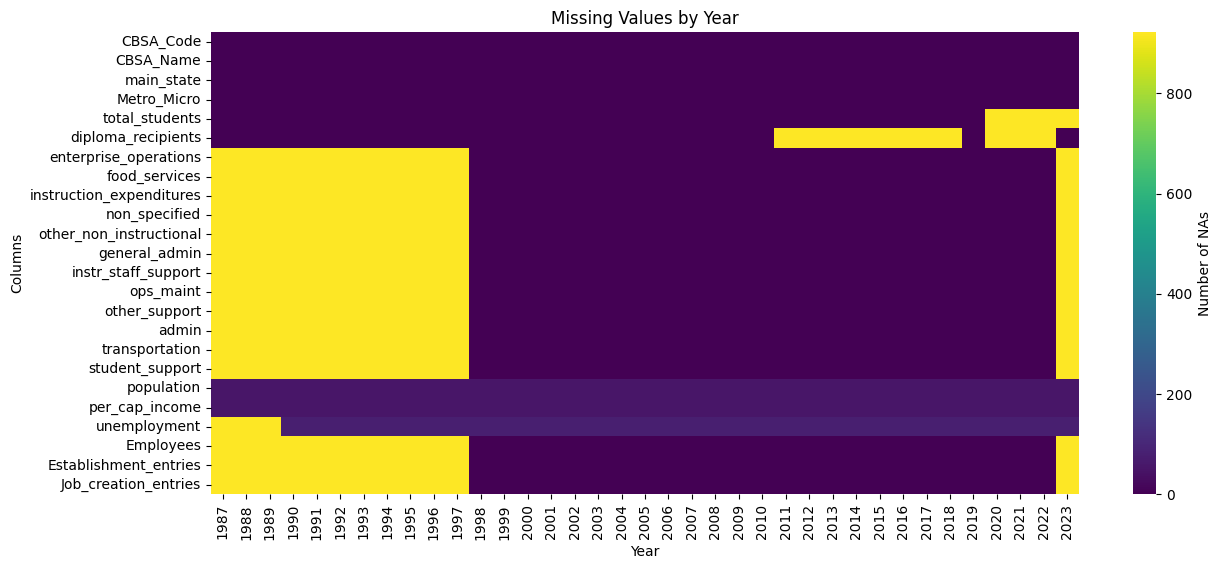

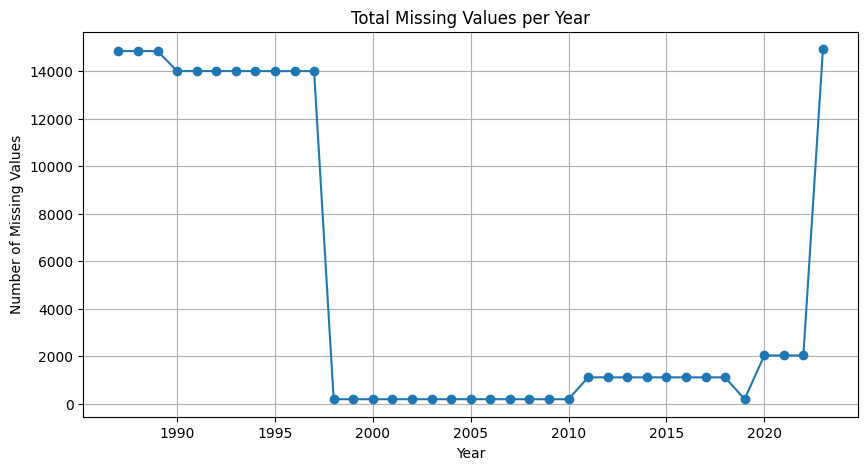

In [ ]:
# Count and visualize missing values per year and column
na_by_year = cbsa_df.drop(columns=["year"]).groupby(cbsa_df["year"]).apply(lambda g: g.isna().sum())

plt.figure(figsize=(14,6))
sns.heatmap(na_by_year.T, cmap="viridis", cbar_kws={'label': 'Number of NAs'})
plt.title("Missing Values by Year")
plt.xlabel("Year")
plt.ylabel("Columns")
plt.show()

# Count and visualize total NAs across all columns per year
na_totals = cbsa_df.drop(columns=["year"]).groupby(cbsa_df["year"]).apply(lambda g: g.isna().sum().sum())

plt.figure(figsize=(10,5))
na_totals.plot(kind="line", marker="o")
plt.title("Total Missing Values per Year")
plt.xlabel("Year")
plt.ylabel("Number of Missing Values")
plt.grid(True)
plt.show()

As we practically have a lack of data (most importantly for the expenditures) between 1997 and 2020, we will focus on the timeframe between (including) 1998 and 2019.

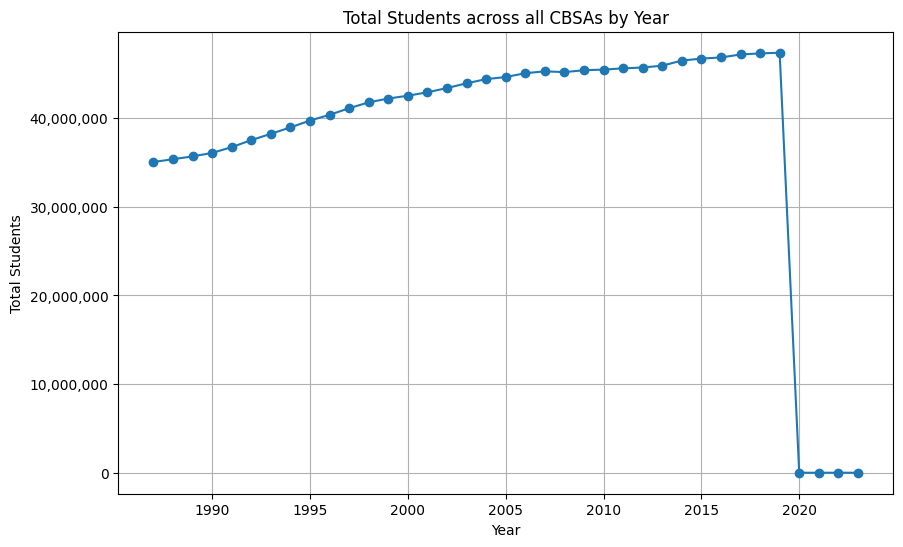

In [ ]:
# Visualize the number of students over the years
students_per_year = cbsa_df.groupby("year")["total_students"].sum()
plt.figure(figsize=(10,6))
ax =students_per_year.plot(kind="line", marker='o')
plt.title("Total Students across all CBSAs by Year")
plt.xlabel("Year")
plt.ylabel("Total Students")
plt.grid(True)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [ ]:
# remove years before 1998 and last years after 2019 from the data set as they are very NA heavy
cbsa_df = cbsa_df[cbsa_df["year"] >= 1998]
cbsa_df = cbsa_df[cbsa_df["year"] <= 2019]

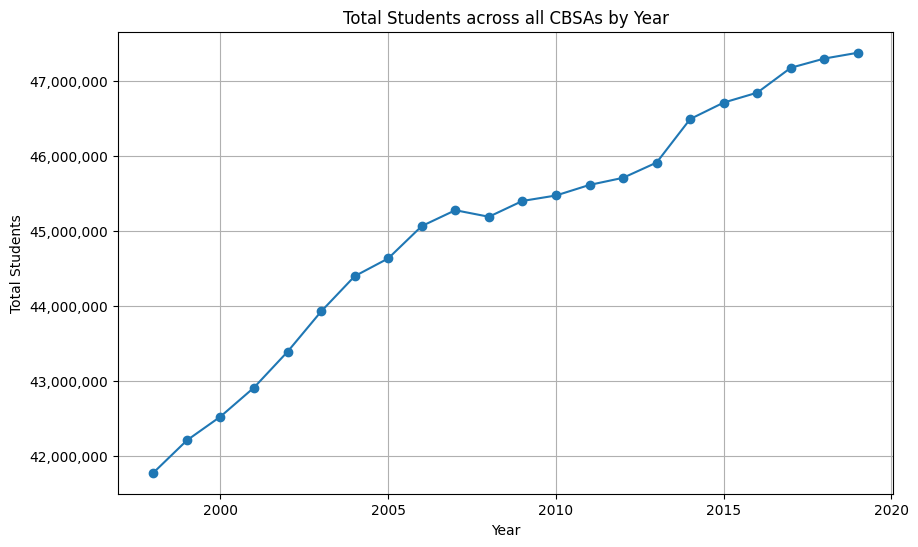

In [ ]:
# Visualize the number of students over the years (after removing NA heavy years)
students_per_year = cbsa_df.groupby("year")["total_students"].sum()
plt.figure(figsize=(10,6))
ax =students_per_year.plot(kind="line", marker='o')
plt.title("Total Students across all CBSAs by Year")
plt.xlabel("Year")
plt.ylabel("Total Students")
plt.grid(True)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

### Categorization of Expenditures into 4 Groups

Since the data on education expenditures includes a lot of varying categories initially, which also change over the years (let it be due to different styles and types of reportings by different entities), we sum up similar variables into 4 total groups, to also tackle missingness and aim for a more complete time series.

In [ ]:
# Categorize the expenditures in a clearer and more comparable way

# Create mapping for the expenditure groups
category_map = {
    "enterprise_operations": "operations",
    "food_services": "student",
    "instruction_expenditures": "instruction",
    "non_specified": "other",
    "other_non_instructional": "other",
    "general_admin": "operations",
    "instr_staff_support": "instruction",
    "ops_maint": "operations",
    "other_support": "other",
    "admin": "operations",
    "transportation": "student",
    "student_support": "student"
}

# Define other identifiers and target variables
other_vars = ['CBSA_Code', 'CBSA_Name', 'main_state', 'year',
              'Metro_Micro', 'total_students', 'diploma_recipients',
              'population', 'per_cap_income', 'unemployment', 'Employees', 'Establishment_entries', 'Job_creation_entries']

# Add id features to new data frame
cbsa_agg = cbsa_df[other_vars].copy()

# Summarize expenditures into categroeis
for category in set(category_map.values()):
    cols = [col for col, cat in category_map.items() if cat == category]
    cbsa_agg[category] = cbsa_df[cols].sum(axis=1, skipna=True)

# Reorder columns
cbsa_agg = cbsa_agg[other_vars + ["operations", "instruction", "student", "other"]]

# Check result
cbsa_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20284 entries, 11 to 34109
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CBSA_Code              20284 non-null  int64  
 1   CBSA_Name              20284 non-null  object 
 2   main_state             20284 non-null  object 
 3   year                   20284 non-null  int64  
 4   Metro_Micro            20284 non-null  int64  
 5   total_students         20284 non-null  float64
 6   diploma_recipients     12908 non-null  float64
 7   population             19140 non-null  float64
 8   per_cap_income         19140 non-null  float64
 9   unemployment           18588 non-null  float64
 10  Employees              20284 non-null  float64
 11  Establishment_entries  20284 non-null  float64
 12  Job_creation_entries   20284 non-null  float64
 13  operations             20284 non-null  float64
 14  instruction            20284 non-null  float64
 15  studen

### Adjust NCES data and personal income for Inflation

Since the NCES data and personal income is not Inflation adjusted, we do this manually. Here, 2019 dollars are used since **1.** it is the most recent complete year in the NCES data and **2.** we avoid the steep  inflation and general economic shenanigans of the COVID years.

In [ ]:
#fetch Consumer Price Index (CPI) data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
cpi_df = pd.read_csv(url)

#convert obervation to datetime and create year column
cpi_df['observation_date'] = pd.to_datetime(cpi_df['observation_date'])
cpi_df['year'] = cpi_df['observation_date'].dt.year

#compute avergae CPI and create dict for easier access
annual_cpi = cpi_df.groupby('year')['CPIAUCSL'].mean().round(1)
cpi_data = annual_cpi.to_dict()

In [ ]:
# Create a helper function for the adjustments
def adjust_for_inflation(
    df, columns, year_column='year', base_year=2019, keep_original=True
    ):
    """
    This function adjusts a DataFrame's columns for inflation. By default,
    2019 dollars are used and the original columns are kept.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    columns : list
        List of columns to adjust for inflation.
    year_column : str, default='year'
        Column containing years.
    base_year : int, default=2019
        Year to adjust all values to.
    keep_original : bool, default=True
        If True, keeps original columns and adds `_adj` versions.
        If False, overwrites original columns with adjusted values.
    """
    #copy data frame and map CPI
    df_adjusted = df.copy()
    df_adjusted['cpi'] = df_adjusted[year_column].map(cpi_data)

    #set base cpi values
    base_cpi_value = cpi_data[base_year]
    df_adjusted['inflation_factor'] = base_cpi_value / df_adjusted['cpi']

    #adjust columns for inflation, check wether original columns shold be kept or overwritten
    for col in columns:
      if col in df_adjusted.columns:
          #create adujusted columns
          df_adjusted[f'{col}_adj'] = df_adjusted[col] * df_adjusted['inflation_factor']
          #check if old columns  should be removed
          if not keep_original:
            df_adjusted = df_adjusted.drop(columns=[col])

    #remove helper columns and return data frame
    df_adjusted = df_adjusted.drop(['cpi', 'inflation_factor'], axis=1)
    return df_adjusted

In [ ]:
#list all columns that should be inflation adjusted
financial_columns = ["operations", "instruction", "student", "other", "per_cap_income"]

#apply helper function, removing old columns
cbsa_agg = adjust_for_inflation(cbsa_agg,columns=financial_columns,keep_original=False)

#convert all numeric columns to display without scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)

#quick check data frame
cbsa_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20284 entries, 11 to 34109
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CBSA_Code              20284 non-null  int64  
 1   CBSA_Name              20284 non-null  object 
 2   main_state             20284 non-null  object 
 3   year                   20284 non-null  int64  
 4   Metro_Micro            20284 non-null  int64  
 5   total_students         20284 non-null  float64
 6   diploma_recipients     12908 non-null  float64
 7   population             19140 non-null  float64
 8   unemployment           18588 non-null  float64
 9   Employees              20284 non-null  float64
 10  Establishment_entries  20284 non-null  float64
 11  Job_creation_entries   20284 non-null  float64
 12  operations_adj         20284 non-null  float64
 13  instruction_adj        20284 non-null  float64
 14  student_adj            20284 non-null  float64
 15  other_

---
## Preliminary and Exploratory Data Analysis and Visualization
- Investigate long-term relationships between education spending and economic outcomes.
- Visualize trends and perform cross-regional comparisons using appropriate time-series plots.

---

In [ ]:
# Create a column that summarizes the total expenditures
# Define the columns to sum
exp_columns = ["operations_adj",
               "instruction_adj",
               "student_adj",
               "other_adj"
]

# Create new total expenditures column
cbsa_agg["total_expenditure"] = cbsa_agg[exp_columns].sum(axis=1)

### Creation of Total Expenditure Variable and Visualisation

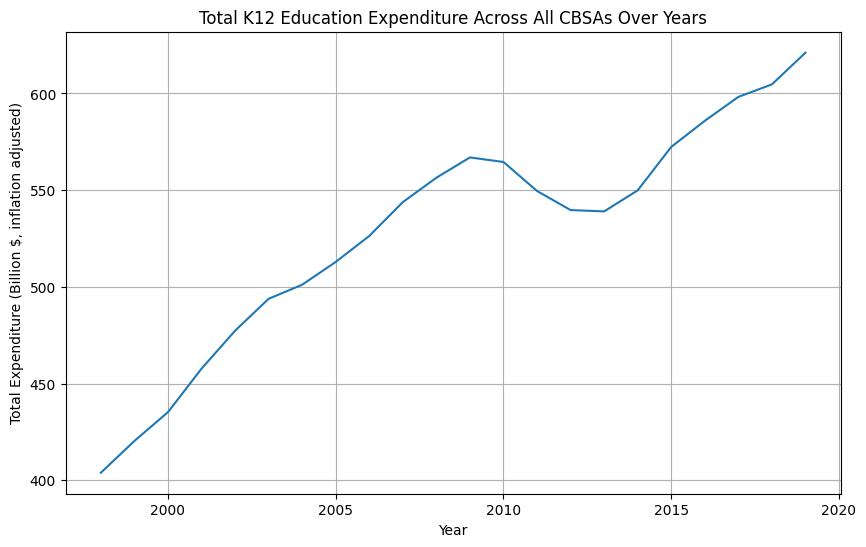

In [ ]:
#group expenditure by year and convert to billions
total_exp_per_year = cbsa_agg.groupby("year")["total_expenditure"].sum()
total_exp_per_year = total_exp_per_year / 1e9

#plot development
plt.figure(figsize=(10,6))
ax = total_exp_per_year.plot(kind="line")
ax.set_title("Total K12 Education Expenditure Across All CBSAs Over Years")
ax.set_xlabel("Year")
ax.set_ylabel("Total Expenditure (Billion $, inflation adjusted)")
ax.grid(True)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

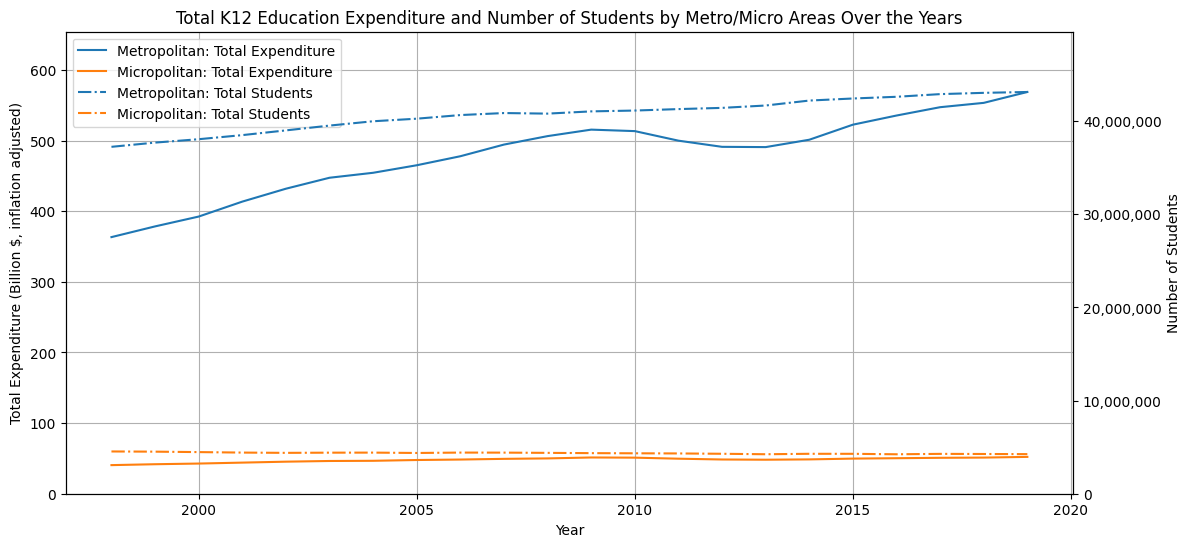

In [ ]:
#aggregate total expenditures by metro micro areas
agg_data = cbsa_agg.groupby(["year", "Metro_Micro"])[["total_expenditure", "total_students"]].sum().unstack()
agg_data.columns = [f"{'Metropolitan' if col[1]==1 else 'Micropolitan'}_{col[0]}" for col in agg_data.columns]

#plot of development of expenditure and number of students
fig, ax1 = plt.subplots(figsize=(13,6))

#first plot expenditure
agg_data[['Metropolitan_total_expenditure', 'Micropolitan_total_expenditure']].plot(ax=ax1, style=['-','-'])
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Expenditure (Billion $, inflation adjusted)")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax1.grid(True)

##add a bit of padding so the legend fits
y1_max = agg_data[['Metropolitan_total_expenditure', 'Micropolitan_total_expenditure']].max().max()
ax1.set_ylim(0, y1_max * 1.15)

#secondly plot number of students
ax2 = ax1.twinx()
agg_data[['Metropolitan_total_students', 'Micropolitan_total_students']].plot(
    ax=ax2, style=['-.', '-.'], color=['tab:blue','tab:orange'])

ax2.set_ylabel("Number of Students")
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

#add a bit of padding so the legend fits
y2_max = agg_data[['Metropolitan_total_students', 'Micropolitan_total_students']].max().max()
ax2.set_ylim(0, y2_max * 1.15)

#combine legends and add custom labels
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
custom_labels = [
    'Metropolitan: Total Expenditure',
    'Micropolitan: Total Expenditure',
    'Metropolitan: Total Students',
    'Micropolitan: Total Students'
]
ax1.legend(lines_1 + lines_2, custom_labels, loc='upper left', title=None)
ax2.get_legend().remove()

ax1.set_title("Total K12 Education Expenditure and Number of Students by Metro/Micro Areas Over the Years")
plt.show()

-> While student numbers rise steadily in the Metropolitan areas there seems to be a small decline in Micropolitan areas. Interestingly while the total expenditures in Metro areas increases rabidly within 25 years, the expenditure in Micro areas only  sees a small increase.

/tmp/ipython-input-1811952037.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cbsa_agg["exp_per_student"].replace([np.inf, -np.inf], np.nan, inplace=True)


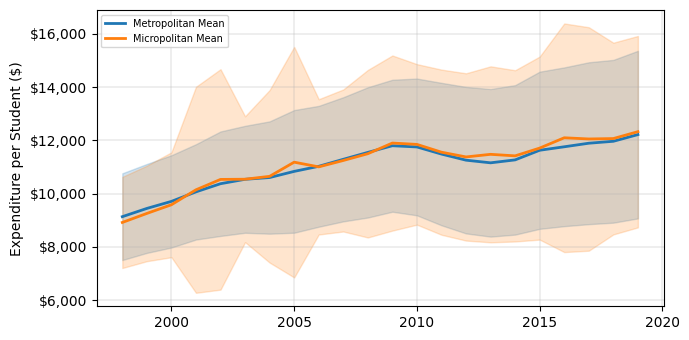

In [ ]:
# LATEX GRAPH
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

#compute per student expenditre
cbsa_agg["exp_per_student"] = cbsa_agg["total_expenditure"] / cbsa_agg["total_students"]
cbsa_agg["exp_per_student"].replace([np.inf, -np.inf], np.nan, inplace=True)

#mean and standarard deviation by year
agg_stats = cbsa_agg.groupby(["year", "Metro_Micro"])["exp_per_student"].agg(['mean', 'std']).unstack()
agg_stats.columns = [f"{'Metropolitan' if col[1]==1 else 'Micropolitan'}_{col[0]}" for col in agg_stats.columns]

#plot mean
fig, ax = plt.subplots(figsize=(7, 3.5))
years = agg_stats.index

# Metropolitan
if 'Metropolitan_mean' in agg_stats.columns:
    mean_metro = agg_stats['Metropolitan_mean']
    std_metro = agg_stats['Metropolitan_std']
    ax.plot(years, mean_metro, color='tab:blue', linewidth=2, label='Metropolitan Mean')
    ax.fill_between(years, mean_metro - std_metro, mean_metro + std_metro, color='tab:blue', alpha=0.2)

# Micropolitan
if 'Micropolitan_mean' in agg_stats.columns:
    mean_micro = agg_stats['Micropolitan_mean']
    std_micro = agg_stats['Micropolitan_std']
    ax.plot(years, mean_micro, color='tab:orange', linewidth=2, label='Micropolitan Mean')
    ax.fill_between(years, mean_micro - std_micro, mean_micro + std_micro, color='tab:orange', alpha=0.2)

#label/styling
ax.set_xlabel("")
ax.set_ylabel("Expenditure per Student ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.grid(True, linewidth=0.3)
ax.legend(fontsize=7)
ax.set_title("")

plt.tight_layout()

#save plot
plt.savefig("exp_per_student_trend.png", dpi=600, bbox_inches="tight")  # high-res PNG

plt.show()


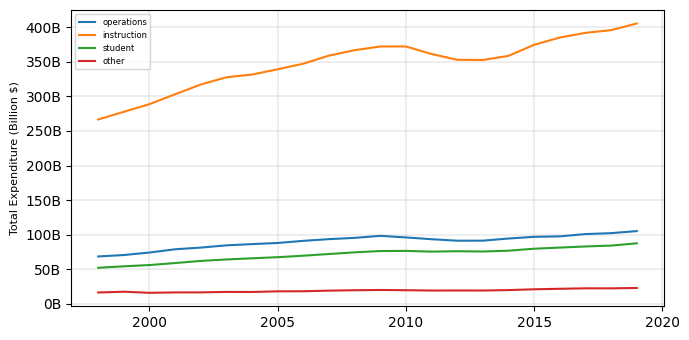

In [ ]:
# LATEX GRAPH
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

#aggreagte yearly expenditure
yearly_exp = cbsa_agg.groupby("year")[["operations_adj", "instruction_adj", "student_adj", "other_adj"]].sum()

#plot
plt.figure(figsize=(7,3.5))+

for col in yearly_exp.columns:
    plt.plot(yearly_exp.index, yearly_exp[col], label=col.replace("_adj",""))

plt.xlabel("")
plt.ylabel("Total Expenditure (Billion $)", fontsize=8)
plt.title("")
plt.grid(True, linewidth=0.3)
plt.legend(fontsize=6)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e9:,.0f}B'))

plt.tight_layout()

#save pciture
plt.savefig("education_exp_by_category.png", dpi=600, bbox_inches="tight")

plt.show()



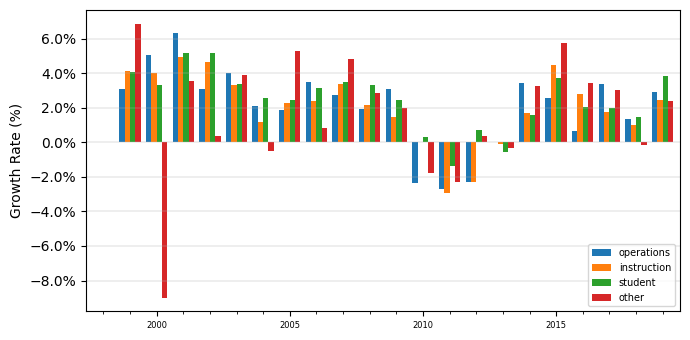

In [ ]:
# LATEX GRAPH
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Define expenditure columns
exp_columns = ["operations_adj", "instruction_adj", "student_adj", "other_adj"]

# Aggregate yearly totals
yearly_totals = cbsa_agg.groupby('year')[exp_columns].sum()

# Calculate growth rates
growth_rates = yearly_totals.pct_change() * 100  # convert to %

# Plot (LaTeX-style)
fig, ax = plt.subplots(figsize=(7, 3.5))

growth_rates.plot(kind='bar', ax=ax, width=0.8)

# Y-axis
ax.set_ylabel("Growth Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# X-axis: major ticks every 5 years
years = growth_rates.index
major_ticks = [i for i, y in enumerate(years) if y % 5 == 0]
ax.set_xticks(major_ticks)
ax.set_xticklabels([y for y in years if y % 5 == 0], rotation=0, fontsize=6)

# Minor ticks for all years
ax.set_xticks(range(len(years)), minor=True)

# Clean legend labels
clean_labels = [col.replace("_adj", "") for col in exp_columns]
ax.legend(clean_labels, fontsize=7, loc='lower right')

# Remove x-label and title for LaTeX style
ax.set_xlabel("")
ax.set_title("")

# Grid and layout
ax.grid(axis='y', linewidth=0.3)
plt.tight_layout()

# Save for LaTeX
plt.savefig("growth_rates_expenditures.png", dpi=600, bbox_inches="tight")
plt.show()


-> shows the steady increase in spending (except during and after the financial crisis of 2008). Furthermore also shows  that the "other" category was  ofthen  used to bundle spending that should be in the other categroies, for example a change in categorization in 2000.

### Visualisation of Target Variables

In [ ]:
desc_table_data = cbsa_agg.drop(columns=[
    "CBSA_Code", "Metro_Micro", "diploma_recipients", "year",
    "Employees", "Establishment_entries", "total_expenditure"
])

# 2. Replace all zeros with NaN in numeric columns
num_cols = desc_table_data.select_dtypes(include='number').columns
desc_table_data[num_cols] = desc_table_data[num_cols].replace(0, np.nan)

# 3. Define desired row order
row_order = [
    "total_students",
    "population",
    "operations_adj",
    "instruction_adj",
    "student_adj",
    "other_adj",
    "per_cap_income_adj",
    "Job_creation_entries",
    "unemployment"
]

# 4. Compute description, reorder rows, round, and add median
desc_table_data.describe().T.loc[row_order].round(2)

,count,mean,std,min,25%,50%,75%,max
total_students,20232.0,4.899662e+04,1.615932e+05,502.00,6419.75,11835.00,2.796450e+04,2.719439e+06
population,19140.0,3.226512e+05,1.071457e+06,11944.00,40735.00,76902.00,1.882778e+05,2.013311e+07
operations_adj,20243.0,9.790051e+07,3.880952e+08,40786.50,12025195.14,22224084.33,5.261747e+07,1.012608e+10
instruction_adj,20262.0,3.772144e+08,1.629723e+09,500841.72,42728587.66,82063498.17,2.023845e+08,4.525531e+10
student_adj,20262.0,7.757834e+07,3.055674e+08,58205.93,9385310.10,17731121.64,4.456104e+07,8.049666e+09
other_adj,20231.0,2.093350e+07,8.235393e+07,1080.27,1655037.93,3596000.00,1.102835e+07,1.809441e+09
per_cap_income_adj,19140.0,4.061349e+04,9.511300e+03,14629.80,35028.03,38858.60,4.419015e+04,1.890600e+05
Job_creation_entries,20282.0,5.852970e+03,2.218179e+04,25.00,446.00,962.00,2.799500e+03,5.148720e+05
unemployment,18588.0,5.970000e+00,2.630000e+00,0.70,4.20,5.40,7.200000e+00,2.990000e+01


#### Income per Capita

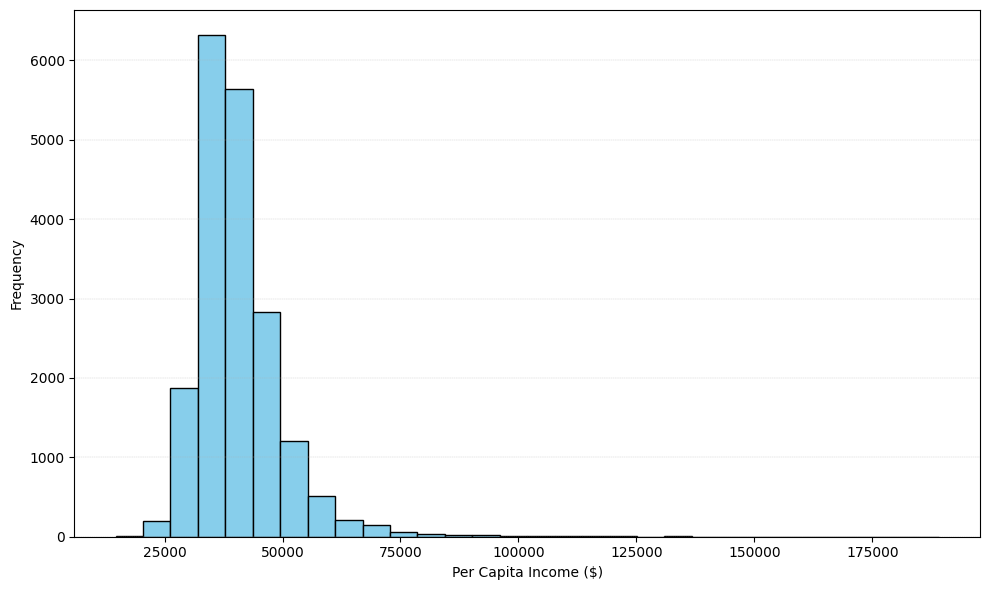

In [ ]:
# LATEX GRAPH (Appendix): Histogram of per_cap_income_adj
fig, ax = plt.subplots(figsize=(10,6))  # appendix: no two-column restriction

ax.hist(cbsa_agg["per_cap_income_adj"].dropna(), bins=30,
        color="skyblue", edgecolor="black")

ax.set_xlabel("Per Capita Income ($)", fontsize=10)
ax.set_ylabel("Frequency", fontsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.7)

plt.tight_layout()

# Save high-res for LaTeX appendix
plt.savefig("hist_per_cap_income_appendix.png", dpi=600, bbox_inches="tight")
plt.show()


Income is normally distributed with a right skew and some outliers for higher values.

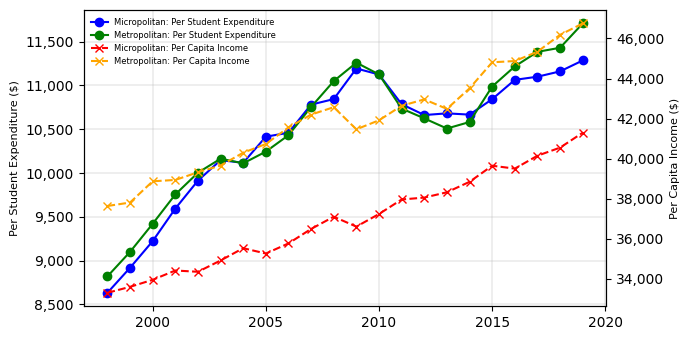

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

#per student expenditure
cbsa_agg["per_student_expenditure"] = cbsa_agg["total_expenditure"] / cbsa_agg["total_students"]

# Aggregate: median across CBSAs by year & Metro/Micro
yearly_grouped = cbsa_agg.groupby(["year", "Metro_Micro"])[
    ["per_student_expenditure", "per_cap_income_adj"]
].median().unstack()

exp = yearly_grouped["per_student_expenditure"]
pci = yearly_grouped["per_cap_income_adj"]

#plot
fig, ax1 = plt.subplots(figsize=(7,3.5))

# Per student expenditure
ax1.plot(exp.index, exp[0], color='blue', marker='o', label='Micropolitan: Per Student Expenditure')
ax1.plot(exp.index, exp[1], color='green', marker='o', label='Metropolitan: Per Student Expenditure')
ax1.set_ylabel(r"Per Student Expenditure (\$)", fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, linewidth=0.3)

# Per capita income (secondary axis)
ax2 = ax1.twinx()
ax2.plot(pci.index, pci[0], color='red', marker='x', linestyle='--', label='Micropolitan: Per Capita Income')
ax2.plot(pci.index, pci[1], color='orange', marker='x', linestyle='--', label='Metropolitan: Per Capita Income')
ax2.set_ylabel(r"Per Capita Income (\$)", fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=6, frameon=False)

plt.tight_layout()

# Save high-res
plt.savefig("exp_vs_income_trends.png", dpi=600, bbox_inches="tight")
plt.show()


-> while the per capita income has reliviely small differences between Metro and micro areas the total expenditures are vastly different. This miight be due to the extremely large Metro areas like Chicago, LA, New York etc. increasing total spending
The seems to be at least some positive relationship between dexpenditure and personal income


#### Job Creation by Firm Births

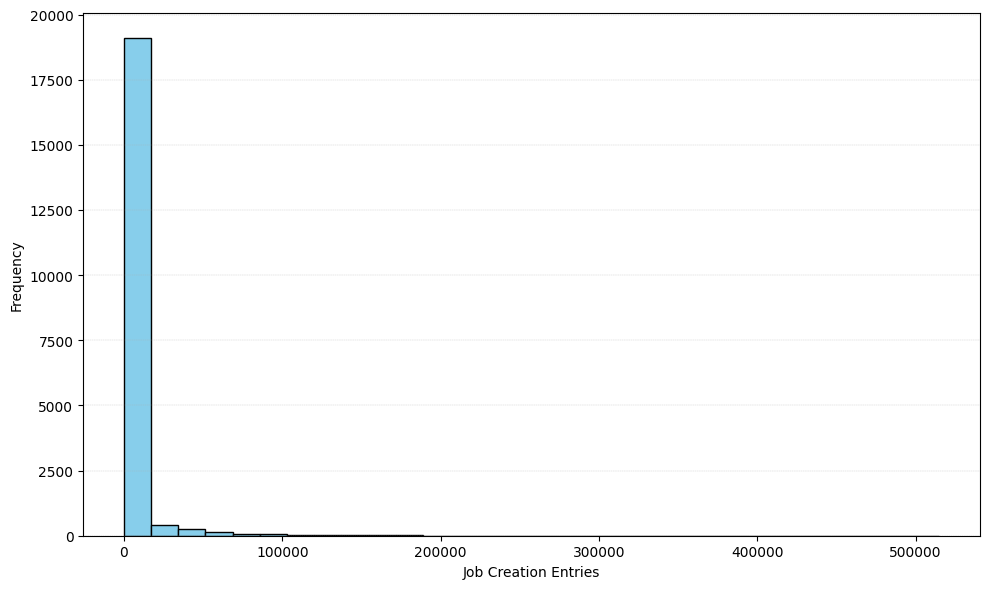

In [ ]:
# LATEX GRAPH (Appendix): Histogram of Job_creation_entries
fig, ax = plt.subplots(figsize=(10,6))  # appendix: full-width

ax.hist(cbsa_agg["Job_creation_entries"].dropna(), bins=30,
        color="skyblue", edgecolor="black")

ax.set_xlabel("Job Creation Entries", fontsize=10)
ax.set_ylabel("Frequency", fontsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.7)

plt.tight_layout()

# Save high-res for LaTeX appendix
plt.savefig("hist_job_creation_appendix.png", dpi=600, bbox_inches="tight")
plt.show()


The variable seems to be very skewed, lets visualize it with a log transformed Histogram.

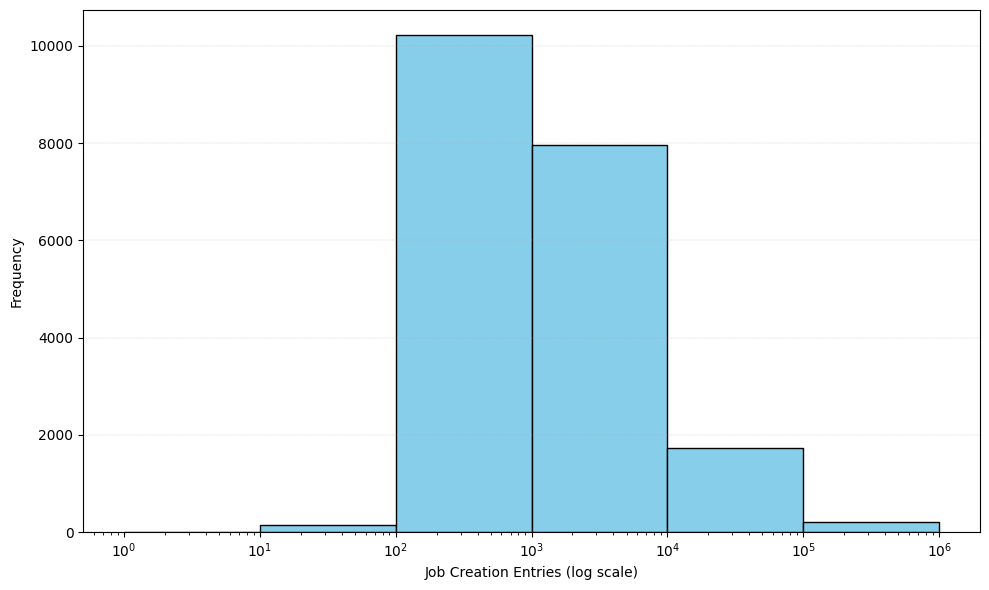

In [ ]:
# LATEX GRAPH (Appendix): Log-binned Histogram of Job Creation Entries
# Define logarithmic bins (powers of 10)
bins = np.logspace(0, 6, num=7)  # from 10^0=1 to 10^6=1,000,000

fig, ax = plt.subplots(figsize=(10,6))  # appendix: full-width

ax.hist(cbsa_agg["Job_creation_entries"].dropna(), bins=bins,
        color="skyblue", edgecolor="black")

ax.set_xscale("log")  # logarithmic x-axis
ax.set_xlabel("Job Creation Entries (log scale)", fontsize=10)
ax.set_ylabel("Frequency", fontsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.7)

plt.tight_layout()

# Save high-res for LaTeX appendix
plt.savefig("hist_job_creation_log_appendix.png", dpi=600, bbox_inches="tight")
plt.show()


This shows that a log transformation is needed for the Job Creation Variable for further analysis.

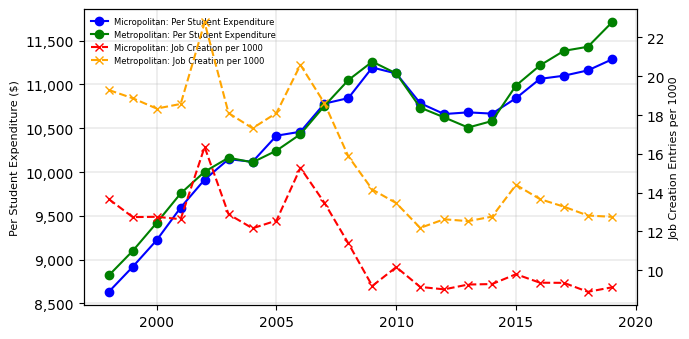

In [ ]:
# LATEX GRAPH for Job creation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------
# 1. Compute derived variables
# ------------------------------------------------------
cbsa_agg["per_student_expenditure"] = cbsa_agg["total_expenditure"] / cbsa_agg["total_students"]
cbsa_agg["job_creation_per_1000"] = cbsa_agg["Job_creation_entries"] / cbsa_agg["population"] * 1000

# Aggregate: median across CBSAs by year & Metro/Micro
yearly_grouped = cbsa_agg.groupby(["year", "Metro_Micro"])[
    ["per_student_expenditure", "job_creation_per_1000"]
].median().unstack()

exp  = yearly_grouped["per_student_expenditure"]
jobs = yearly_grouped["job_creation_per_1000"]

# ------------------------------------------------------
# 2. Plot in LaTeX style
# ------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(7,3.5))  # fits LaTeX two-column

# Per student expenditure (primary axis, $)
ax1.plot(exp.index, exp[0], color='blue', marker='o', label='Micropolitan: Per Student Expenditure')
ax1.plot(exp.index, exp[1], color='green', marker='o', label='Metropolitan: Per Student Expenditure')
ax1.set_ylabel(r"Per Student Expenditure (\$)", fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, linewidth=0.3)

# Job creation per capita (secondary axis)
ax2 = ax1.twinx()
ax2.plot(jobs.index, jobs[0], color='red', marker='x', linestyle='--', label='Micropolitan: Job Creation per 1000')
ax2.plot(jobs.index, jobs[1], color='orange', marker='x', linestyle='--', label='Metropolitan: Job Creation per 1000')
ax2.set_ylabel(r"Job Creation Entries per 1000", fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}'))

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=6, frameon=False)

plt.tight_layout()

# Save high-res for LaTeX
plt.savefig("expenditure_vs_jobcreation_trends.png", dpi=600, bbox_inches="tight")
plt.show()


#### Unemployment

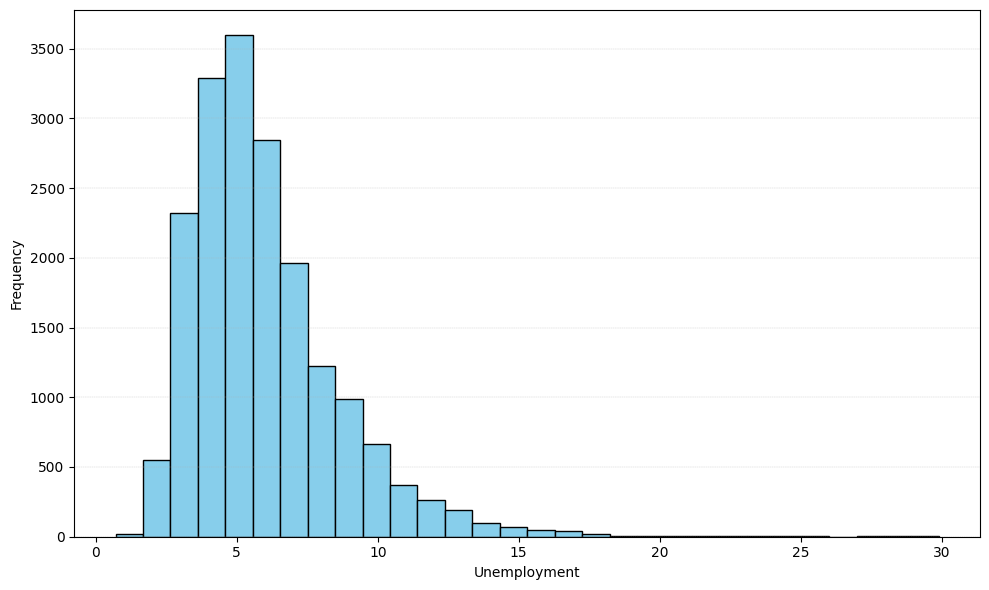

In [ ]:
# LATEX GRAPH (Appendix): Histogram of Unemployment
fig, ax = plt.subplots(figsize=(10,6))  # appendix: full-width

ax.hist(cbsa_agg["unemployment"].dropna(), bins=30,
        color="skyblue", edgecolor="black")

ax.set_xlabel("Unemployment", fontsize=10)
ax.set_ylabel("Frequency", fontsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.7)

plt.tight_layout()

# Save high-res for LaTeX appendix
plt.savefig("hist_unemployment_appendix.png", dpi=600, bbox_inches="tight")
plt.show()


Like income, unemployment is also pretty normally distributed with a small right skew and some outliers towards the right.

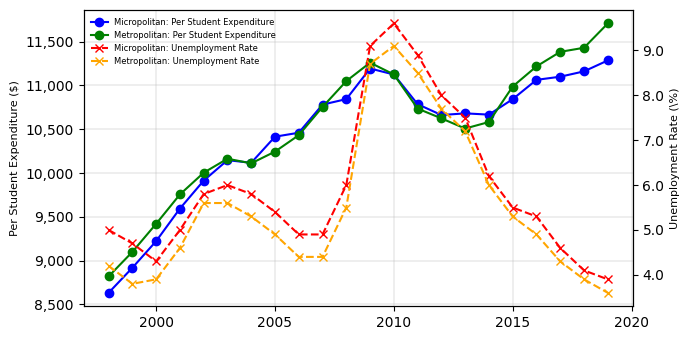

In [ ]:
# LATEX GRAPH

#per student expenditure
cbsa_agg["per_student_expenditure"] = cbsa_agg["total_expenditure"] / cbsa_agg["total_students"]

# Aggregate: median across CBSAs by year & Metro/Micro
yearly_grouped = cbsa_agg.groupby(["year", "Metro_Micro"])[
    ["per_student_expenditure", "unemployment"]
].median().unstack()

exp   = yearly_grouped["per_student_expenditure"]
unemp = yearly_grouped["unemployment"]

#plot
fig, ax1 = plt.subplots(figsize=(7,3.5))

# Per student expenditure (primary axis, $)
ax1.plot(exp.index, exp[0], color='blue', marker='o', label='Micropolitan: Per Student Expenditure')
ax1.plot(exp.index, exp[1], color='green', marker='o', label='Metropolitan: Per Student Expenditure')
ax1.set_ylabel(r"Per Student Expenditure (\$)", fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, linewidth=0.3)

# Unemployment rate (secondary axis, %)
ax2 = ax1.twinx()
ax2.plot(unemp.index, unemp[0], color='red', marker='x', linestyle='--', label='Micropolitan: Unemployment Rate')
ax2.plot(unemp.index, unemp[1], color='orange', marker='x', linestyle='--', label='Metropolitan: Unemployment Rate')
ax2.set_ylabel(r"Unemployment Rate (\%)", fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}'))

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=6, frameon=False)

plt.tight_layout()

# Save high-res for LaTeX
plt.savefig("expenditure_vs_unemp_trends.png", dpi=600, bbox_inches="tight")
plt.show()


-> There seems to be no relationship between unemployment and expenditure, at least on the Federal level. This makes sense since it is dependent on quite a lot of outside factors. However on the Cbsa level there might still be a relationship that is smoothed over by the aggregation. Further below is a graph that shows that unemployment rates vary significantly between states and therefore also CBSAs

### Visualisation of Maps

In [ ]:
#PREP

#fetch shape files
zip_url = "https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Shapefiles/tl_2024_us_cbsa.zip"
r = requests.get(zip_url)
z = zipfile.ZipFile(io.BytesIO(r.content))

# Extract all files into a folder
extract_folder = "repo_downloaded"
z.extractall(extract_folder)


#Automatically find the .shp file
shp_file = None
for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.endswith(".shp"):
            shp_file = os.path.join(root, file)
            break
    if shp_file:
        break

if shp_file is None:
    raise FileNotFoundError("No .shp file found in the extracted ZIP.")

print(f"Found shapefile at: {shp_file}")

#load shapre file
cbsa_shapes = gpd.read_file(shp_file)

Found shapefile at: repo_downloaded/tl_2024_us_cbsa.shp


In [ ]:
#merge shapefile and add variables
#calculate exp per student (again for safety)
cbsa_agg["exp_per_student"] = cbsa_agg["total_expenditure"] / cbsa_agg["total_students"]
cbsa_agg["jobs_per_1000"] = cbsa_agg["Job_creation_entries"] / cbsa_agg["population"] * 1000
cbsa_agg["CBSA_Code"] = cbsa_agg["CBSA_Code"].astype(str)

#merge with shapefile
merged = cbsa_shapes.merge(cbsa_agg, left_on="GEOID", right_on="CBSA_Code")

#filter to continental US only
merged = merged[~merged["main_state"].isin(["AK", "HI"])].to_crs("EPSG:5070")

#years to plot
years = [2000, 2005, 2010, 2015, 2019]

In [ ]:
subset = cbsa_agg.loc[
    cbsa_agg["year"].isin(years),
    ["year", "CBSA_Code", "exp_per_student", "per_cap_income_adj", "jobs_per_1000", "unemployment"]
].copy()
subset = subset.replace([np.inf, -np.inf], np.nan).dropna()

subset.describe(percentiles=[0.05, 0.25, 0.75, 0.95]).T



,count,mean,std,min,5%,25%,50%,75%,95%,max
year,4214.0,2009.805648,6.795124,2000.000000,2000.000000,2005.000000,2010.000000,2015.000000,2019.000000,2019.000000
exp_per_student,4214.0,11109.284838,2987.116718,6014.809288,8019.337481,9429.461356,10490.407268,12010.919335,16140.852185,84124.367864
per_cap_income_adj,4214.0,41035.694189,9534.620298,15347.939605,30337.879647,35403.951365,39334.279182,44736.171519,57120.413017,189060.000000
jobs_per_1000,4214.0,13.924599,7.348243,1.365188,5.584021,9.152454,12.606634,17.103100,26.632031,147.191993
unemployment,4214.0,5.777029,2.773761,1.700000,2.800000,3.900000,5.000000,6.900000,11.600000,29.100000


In [ ]:
exp_min, exp_max = np.percentile(subset["exp_per_student"], [5, 95])
inc_min, inc_max = np.percentile(subset["per_cap_income_adj"], [5, 95])
job_min, job_max = np.percentile(subset["jobs_per_1000"], [5, 95])
unemp_min, unemp_max = np.percentile(subset["unemployment"], [5, 95])

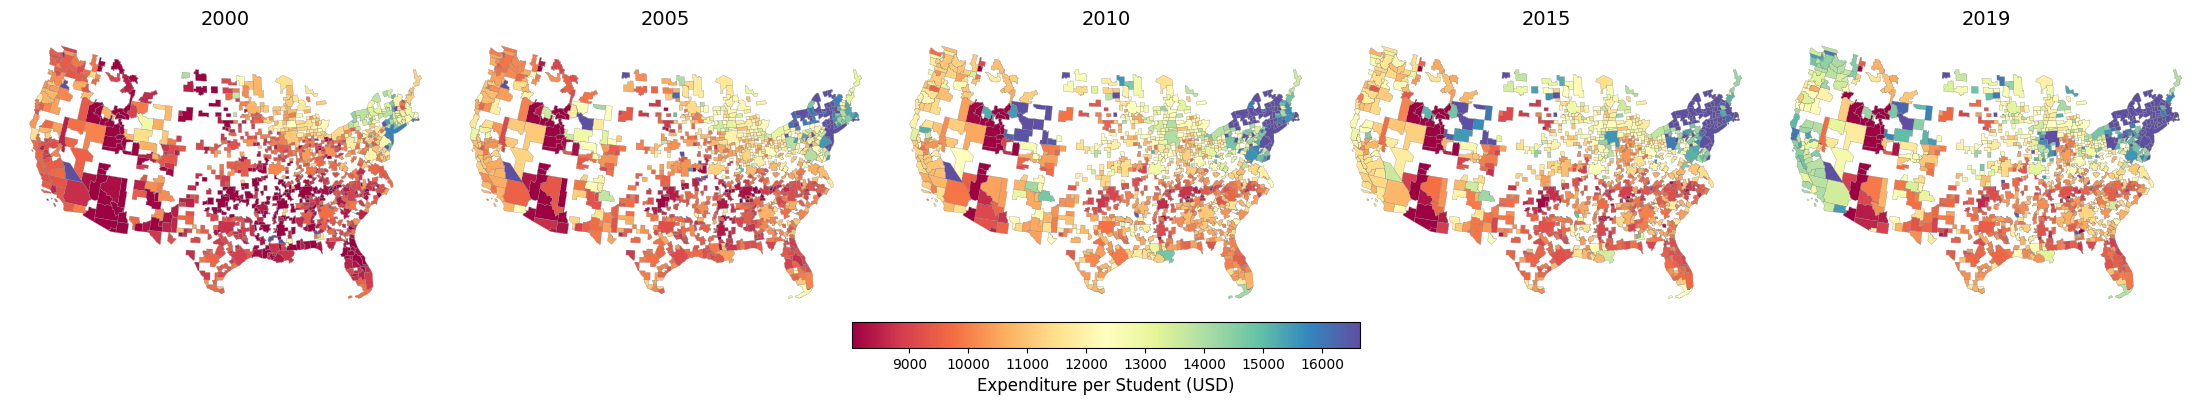

In [ ]:
#plot
fig, axes = plt.subplots(1, len(years), figsize=(22, 6), constrained_layout=True)

vmin, vmax = exp_min, exp_max
for i, year in enumerate(years):
    ax = axes[i]
    merged[merged["year"] == year].plot(
        column="exp_per_student",
        cmap="Spectral",
        linewidth=0.2,
        edgecolor="grey",
        legend=False,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{year}", fontsize=14)
    ax.axis("off")

#add shared colorbar
sm = plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cbar.set_label("Expenditure per Student (USD)", fontsize=12)

plt.savefig("exp_per_student_maps.png", dpi=600, bbox_inches="tight")
plt.show()


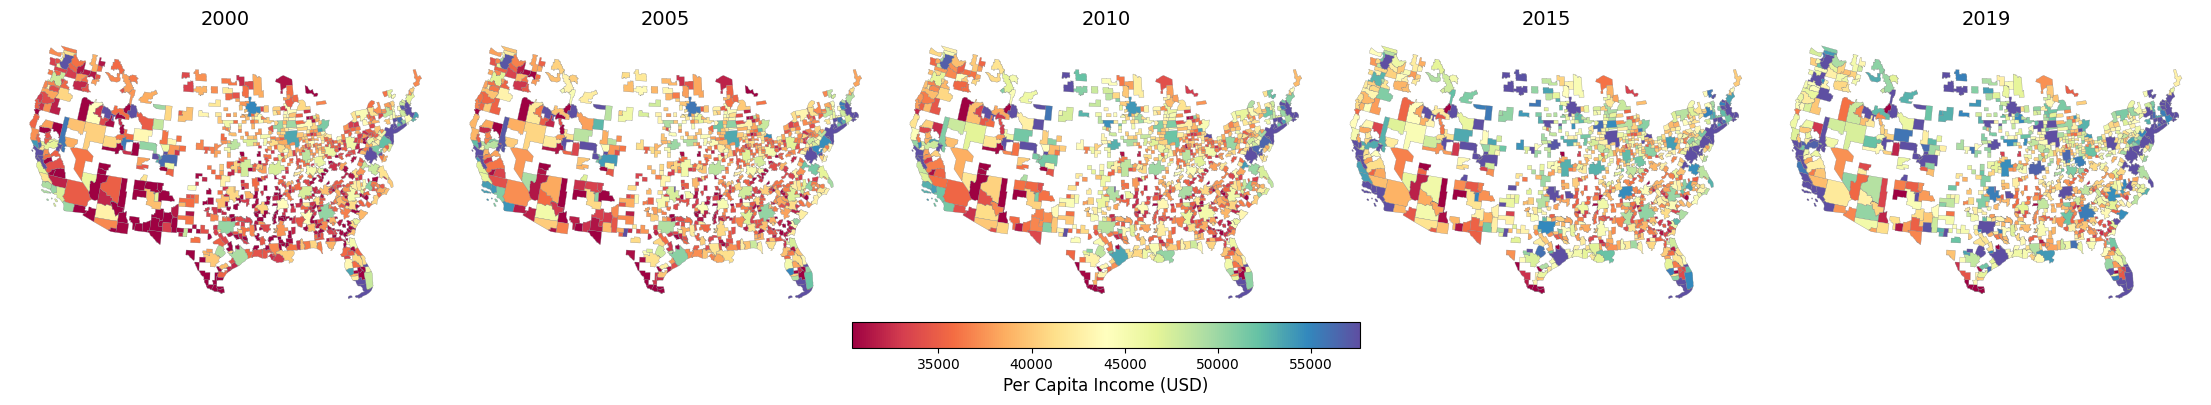

In [ ]:
# Plot
fig, axes = plt.subplots(1, len(years), figsize=(22, 6), constrained_layout=True)

vmin, vmax = inc_min, inc_max

for i, year in enumerate(years):
    ax = axes[i]
    merged[merged["year"] == year].plot(
        column="per_cap_income_adj",
        cmap="Spectral",
        linewidth=0.2,
        edgecolor="grey",
        legend=False,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{year}", fontsize=14)
    ax.axis("off")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cbar.set_label("Per Capita Income (USD)", fontsize=12)

plt.savefig("per_cap_income_maps.png", dpi=600, bbox_inches="tight")
plt.show()


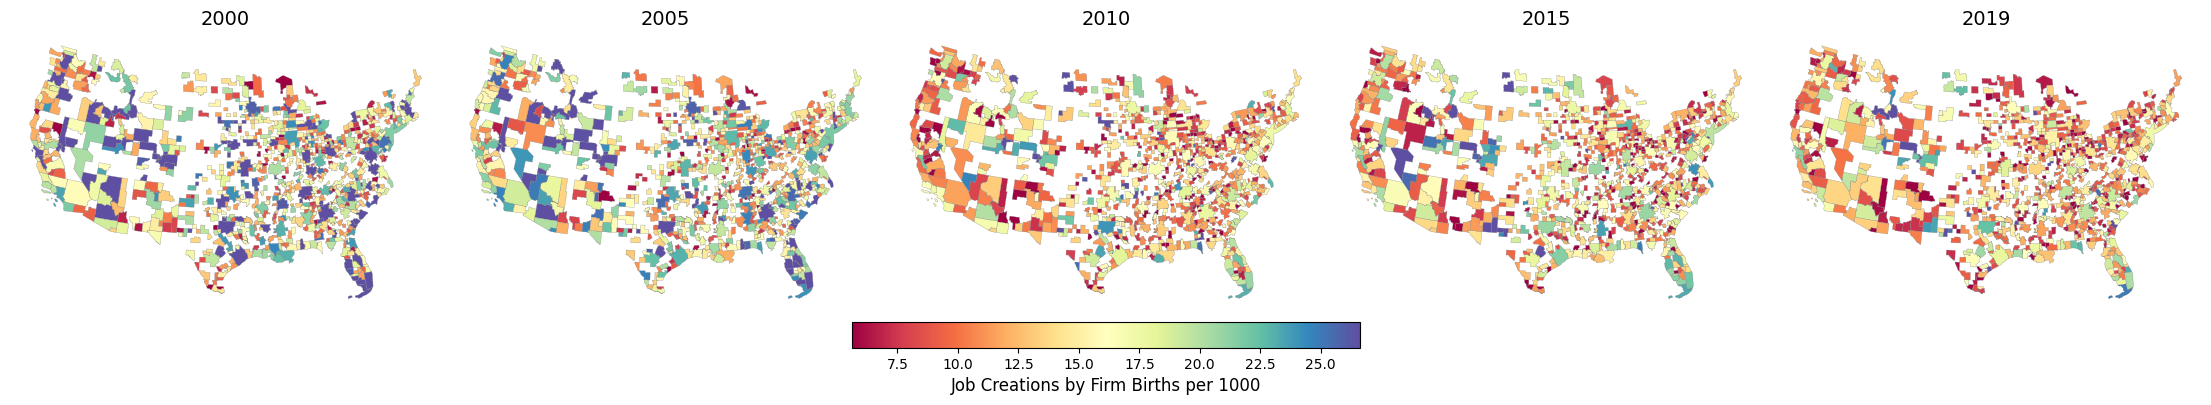

In [ ]:
# Plot
fig, axes = plt.subplots(1, len(years), figsize=(22, 6), constrained_layout=True)

vmin, vmax = job_min, job_max

for i, year in enumerate(years):
    ax = axes[i]
    merged[merged["year"] == year].plot(
        column="jobs_per_1000",
        cmap="Spectral",
        linewidth=0.2,
        edgecolor="grey",
        legend=False,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{year}", fontsize=14)
    ax.axis("off")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="Spectral", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cbar.set_label("Job Creations by Firm Births per 1000", fontsize=12)

plt.savefig("job_creations_1000_maps.png", dpi=600, bbox_inches="tight")
plt.show()


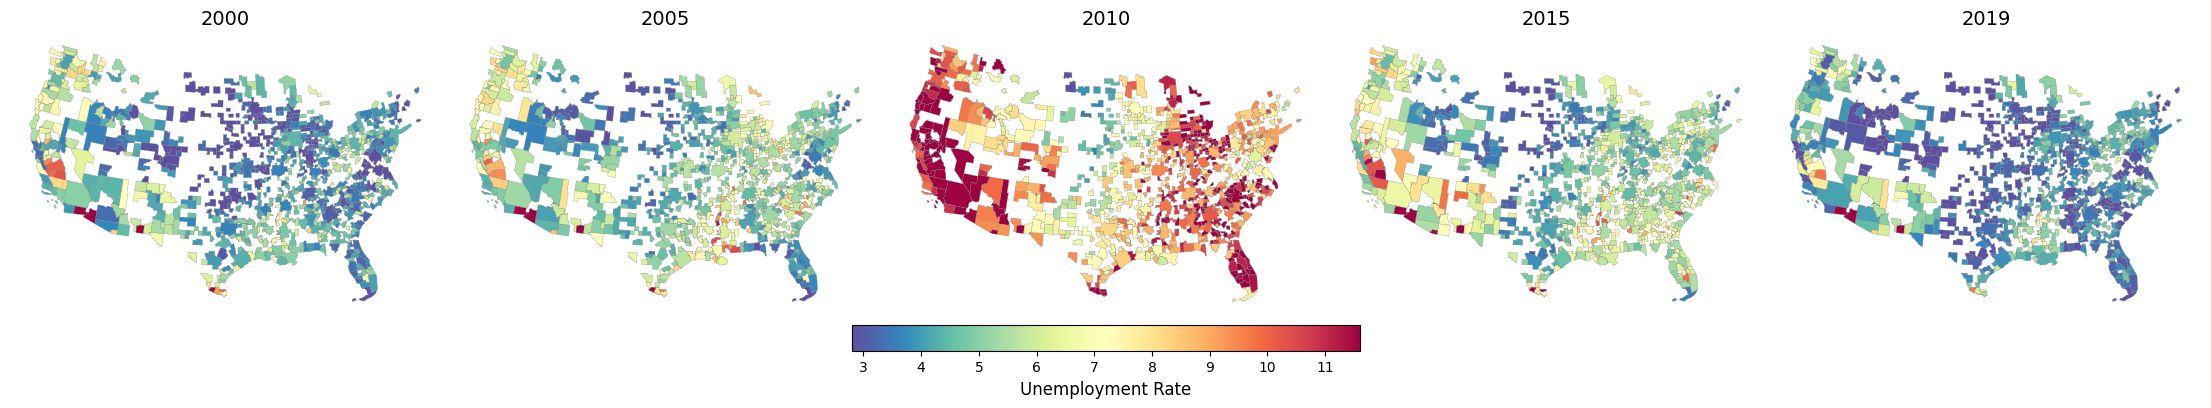

In [ ]:
# Plot
fig, axes = plt.subplots(1, len(years), figsize=(22, 6), constrained_layout=True)

vmin, vmax = unemp_min, unemp_max

for i, year in enumerate(years):
    ax = axes[i]
    merged[merged["year"] == year].plot(
        column="unemployment",
        cmap="Spectral_r",
        linewidth=0.2,
        edgecolor="grey",
        legend=False,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{year}", fontsize=14)
    ax.axis("off")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="Spectral_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.02)
cbar.set_label("Unemployment Rate", fontsize=12)

plt.savefig("unemployment_maps.png", dpi=600, bbox_inches="tight")
plt.show()

#### Target variables trends among themselves

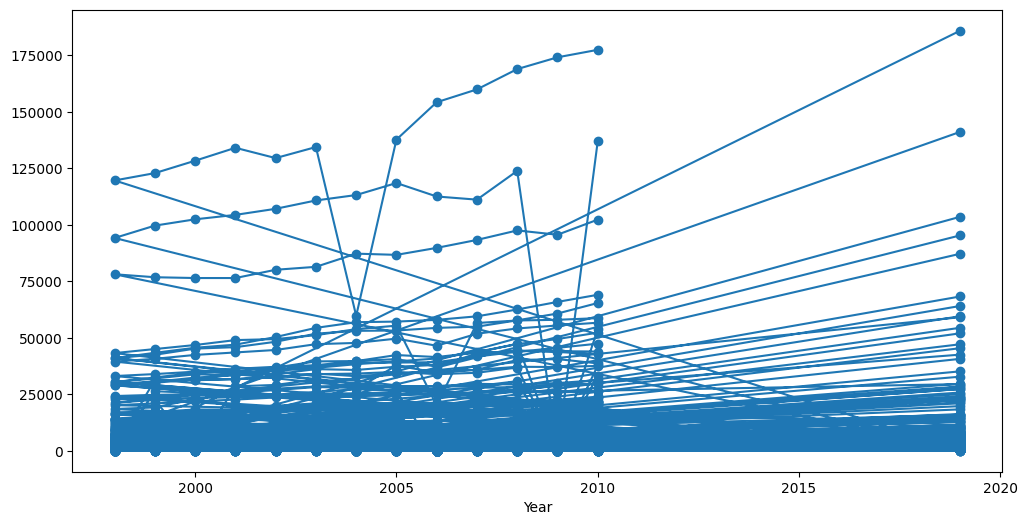

In [ ]:
# Development of diploma recipients over the years (shows that we do not have enough data about diploma recipients even after removing NA heavy years)
plt.figure(figsize=(12,6))
plt.plot(cbsa_agg["year"], cbsa_agg["diploma_recipients"], marker='o')
plt.xlabel("Year")
plt.show()

-> SHows that we do not have enough data to use diploma recipients as target variable

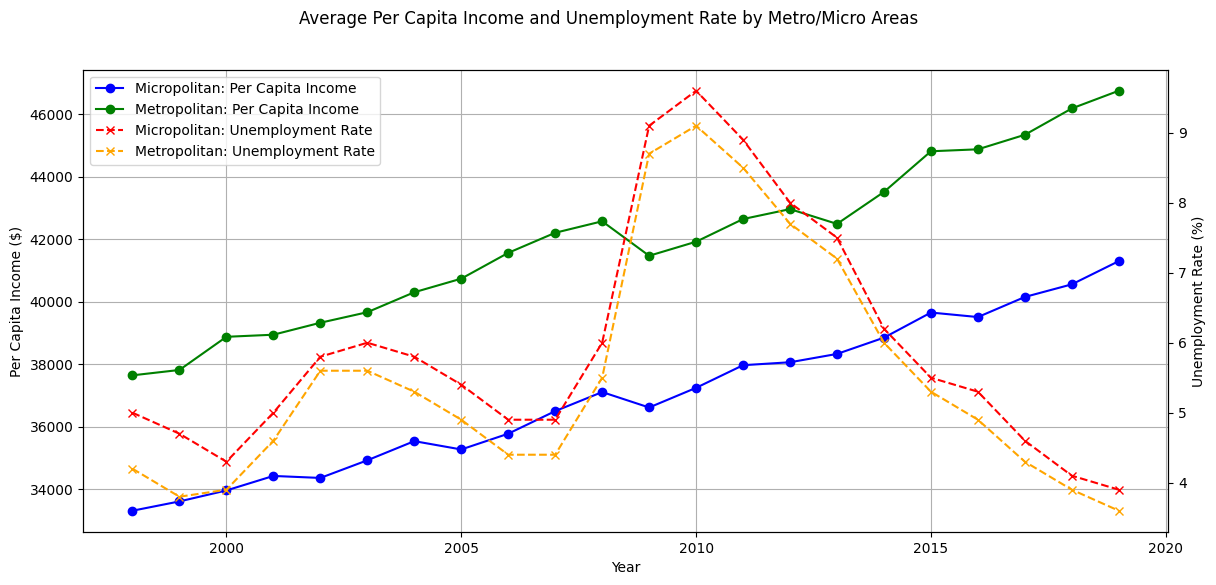

In [ ]:
# Visualize unemployment and personal income over the years
# Aggregate values
yearly_grouped = cbsa_agg.groupby(["year", "Metro_Micro"])[["per_cap_income_adj", "unemployment"]].median().unstack()

# Extract Metro/Micro columns for easier plotting
pci = yearly_grouped["per_cap_income_adj"]
unemp = yearly_grouped["unemployment"]

# Set figure size explicitly
fig, ax1 = plt.subplots(figsize=(14,6))

# Plot per cap income
ax1.plot(pci.index, pci[0], color='blue', marker='o', label='Micro: Per Capita Income')
ax1.plot(pci.index, pci[1], color='green', marker='o', label='Metro: Per Capita Income')
ax1.set_xlabel("Year")
ax1.set_ylabel("Per Capita Income ($)")
ax1.grid(True)

# Plot unemployment rate
ax2 = ax1.twinx()
ax2.plot(unemp.index, unemp[0], color='red', marker='x', linestyle='--', label='Micro: Unemployment Rate')
ax2.plot(unemp.index, unemp[1], color='orange', marker='x', linestyle='--', label='Metro: Unemployment Rate')
ax2.set_ylabel("Unemployment Rate (%)")
fig.suptitle("Average Per Capita Income and Unemployment Rate by Metro/Micro Areas")
# Combine legends and add custom labels
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
custom_labels = [
    'Micropolitan: Per Capita Income',
    'Metropolitan: Per Capita Income',
    'Micropolitan: Unemployment Rate',
    'Metropolitan: Unemployment Rate'
]
ax1.legend(lines_1 + lines_2, custom_labels, loc='upper left', title=None)
plt.show()

-> We can see that the unemployment reflects different economic crisis (recession in the early 90ies, dot com bubble + 9/11 and 2008 financial crisis). Surprisingly personal income does not seem to be affected by these crises.

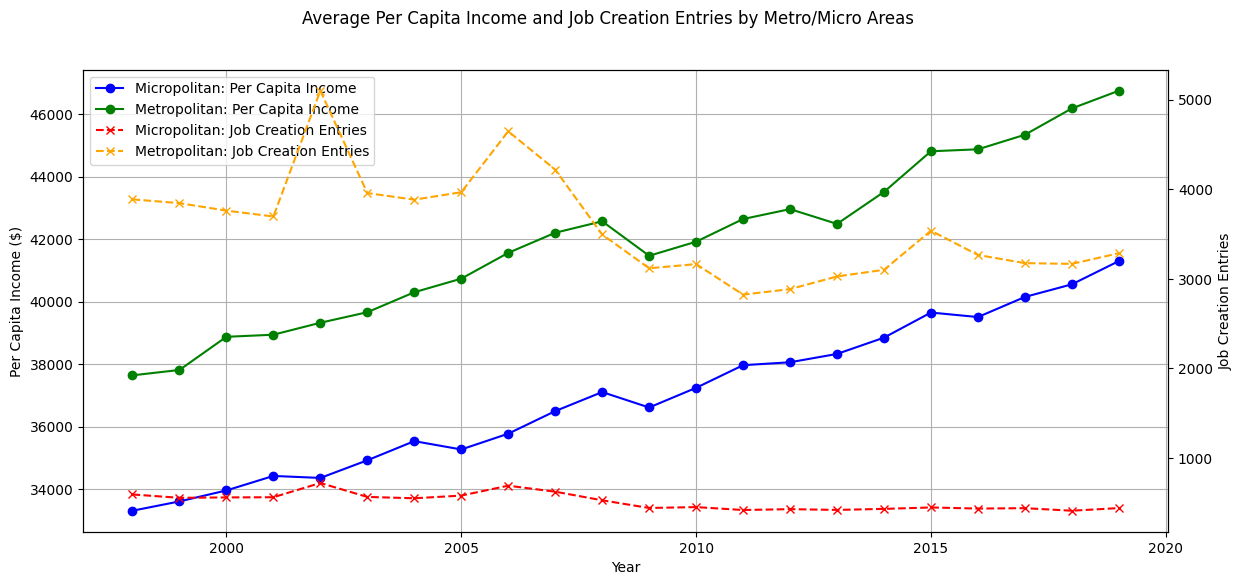

In [ ]:
# Visualize job creation and personal income over the years
# Aggregate values
yearly_grouped = cbsa_agg.groupby(["year", "Metro_Micro"])[["per_cap_income_adj", "Job_creation_entries"]].median().unstack()

# Extract Metro/Micro columns for easier plotting
pci = yearly_grouped["per_cap_income_adj"]
jobs = yearly_grouped["Job_creation_entries"]

# Set figure size explicitly
fig, ax1 = plt.subplots(figsize=(14,6))

# Plot per cap income
ax1.plot(pci.index, pci[0], color='blue', marker='o', label='Micro: Per Capita Income')
ax1.plot(pci.index, pci[1], color='green', marker='o', label='Metro: Per Capita Income')
ax1.set_xlabel("Year")
ax1.set_ylabel("Per Capita Income ($)")
ax1.grid(True)

# Plot job creation entries
ax2 = ax1.twinx()
ax2.plot(jobs.index, jobs[0], color='red', marker='x', linestyle='--', label='Micro: Job Creation Entries')
ax2.plot(jobs.index, jobs[1], color='orange', marker='x', linestyle='--', label='Metro: Job Creation Entries')
ax2.set_ylabel("Job Creation Entries")
fig.suptitle("Average Per Capita Income and Job Creation Entries by Metro/Micro Areas")

# Combine legends and add custom labels
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
custom_labels = [
    'Micropolitan: Per Capita Income',
    'Metropolitan: Per Capita Income',
    'Micropolitan: Job Creation Entries',
    'Metropolitan: Job Creation Entries'
]
ax1.legend(lines_1 + lines_2, custom_labels, loc='upper left', title=None)
plt.show()


-> As the per capita is rising over the years, other than small spikes, job creation by new firm births is rather on the downfall in the selected timeframe, which is odd.

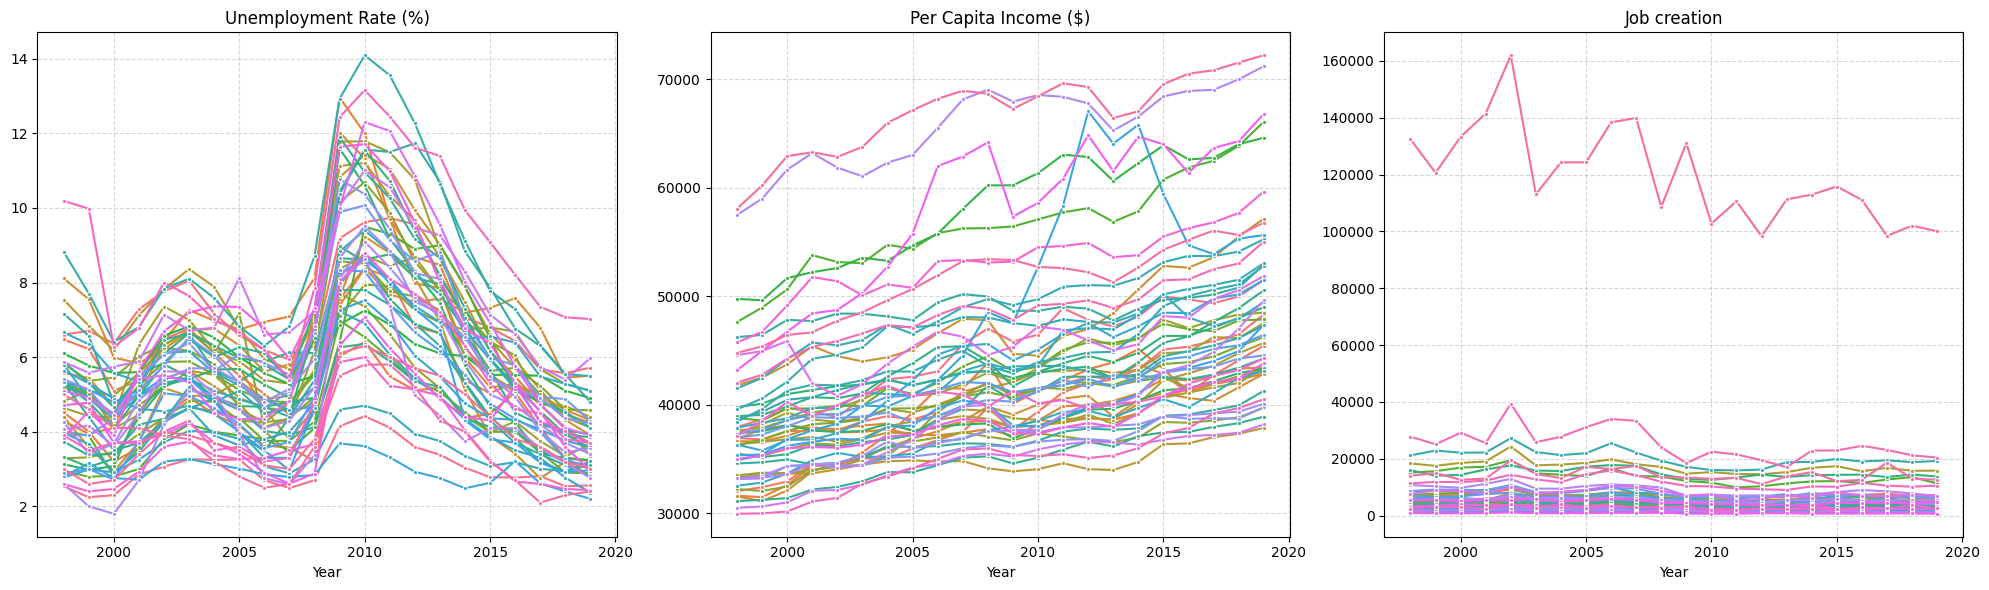

In [ ]:
#visualize targets next to each other
targets = ["unemployment", "per_cap_income_adj", "Job_creation_entries"]
titles = ["Unemployment Rate (%)", "Per Capita Income ($)", "Job creation"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

for ax, target, title in zip(axes, targets, titles):
    sns.lineplot(
        data=cbsa_agg,
        x="year",
        y=target,
        hue="main_state",
        marker=".",
        legend=False,
        errorbar=None,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Quite a lot of variance in the unemployment rates especially around 2008 and 1995/1996 (i.e., in times of crisis). Per capita income is slowly rising in all states with some spikes in some states but otherwise greatly distributed. There is one state that creates way more jobs than all the others, let's see which one it is (big surprise incoming):

In [ ]:
# Compute average Job_creation_entries per state
state_avg = cbsa_agg.groupby("main_state")["Job_creation_entries"].mean()

# Sort descending
state_avg_sorted = state_avg.sort_values(ascending=False)

# Convert to a nice table
state_ranking = state_avg_sorted.reset_index()
state_ranking.columns = ["State", "Average_Job_Creation"]
state_ranking["Rank"] = state_ranking["Average_Job_Creation"].rank(method="first", ascending=False).astype(int)

# Reorder columns
state_ranking = state_ranking[["Rank", "State", "Average_Job_Creation"]]

print(state_ranking.head(5))


   Rank State  Average_Job_Creation
0     1    DC            119,655.41
1     2    RI             25,311.27
2     3    CA             20,335.37
3     4    NY             17,247.17
4     5    FL             14,922.14


So Washington DC creates on average 120,000 jobs per year, with 25,000 in RI being second.

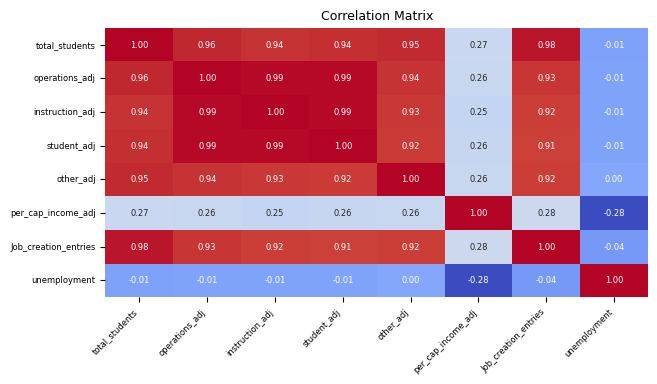

In [ ]:
# ------------------------------------------------------
# Correlation Matrix of Relevant Variables (LaTeX format)
# ------------------------------------------------------

# Explicit variable selection (in desired order)
selected_vars = [
    "total_students",
    "operations_adj",
    "instruction_adj",
    "student_adj",
    "other_adj",
    "per_cap_income_adj",
    "Job_creation_entries",
    "unemployment"
]

numeric_data = cbsa_agg[selected_vars]

# Correlation matrix
corr_matrix = numeric_data.corr()

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    cbar=False,
    annot_kws={"size": 6}, ax=ax
)

ax.set_title("Correlation Matrix", fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(rotation=0, fontsize=6)

# Save high-res PNG for LaTeX
plt.savefig("correlation_matrix.png", dpi=600, bbox_inches="tight")

plt.show()



-> All education related variables show a very high positive correlation among themselves. Income has a small positive correlation with all variables but unemployment, which is negative. Job creation shows a high positive correlation to education expenditure, a smaller one with income and almost none with unemployment. Unemployment seems to have almost no correlations with any other variable, but income.

#### Autocorrelations

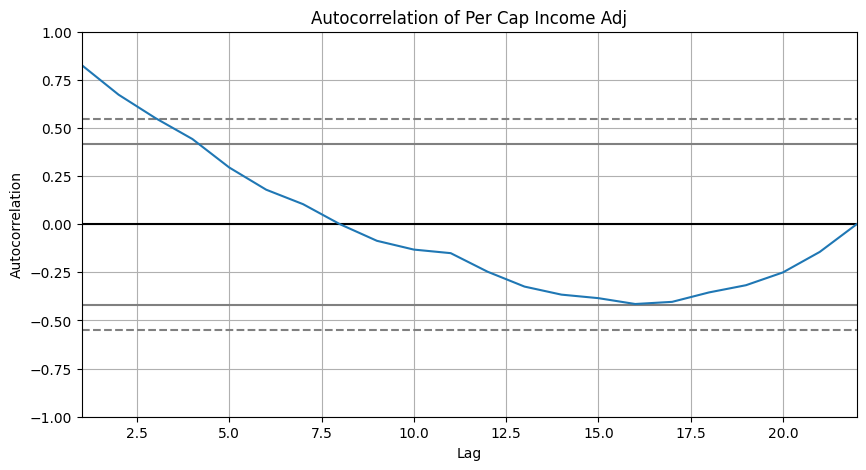

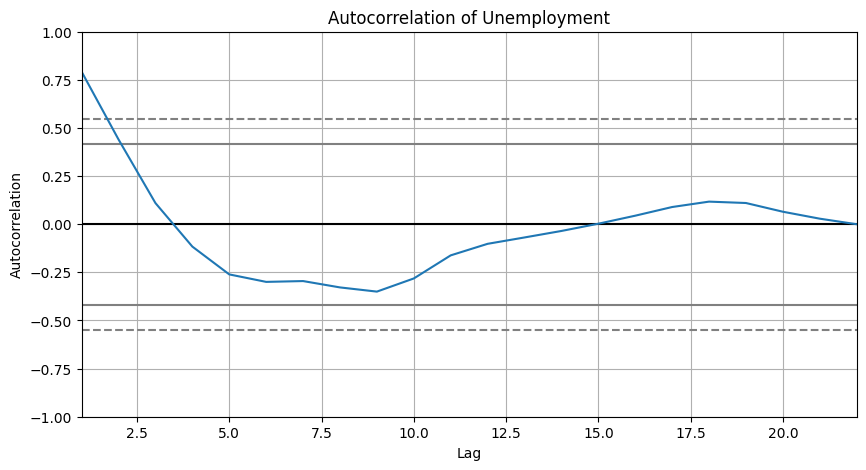

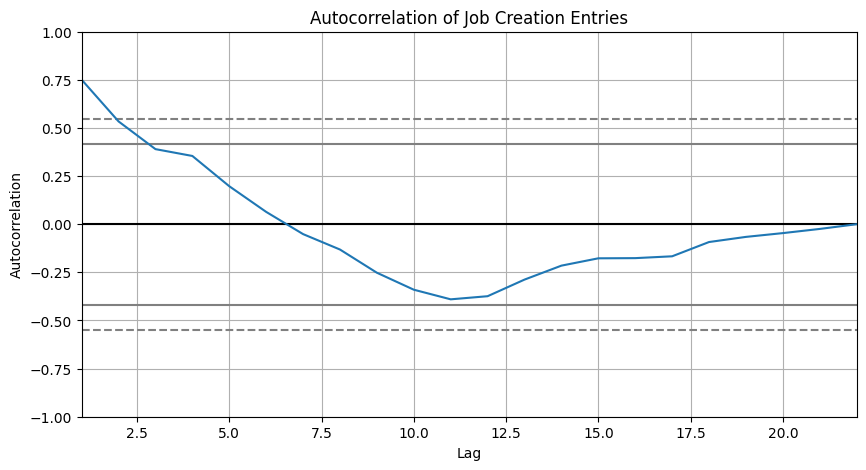

In [ ]:
# Target variables
target_cols = ['per_cap_income_adj', 'unemployment', 'Job_creation_entries']

# Aggregate over years (mean automatically ignores NaNs)
yearly_agg = cbsa_agg.groupby('year')[target_cols].mean()

# Plot autocorrelations column-wise, ignoring only that column's NaNs
for col in target_cols:
    plt.figure(figsize=(10,5))
    autocorrelation_plot(yearly_agg[col].dropna())
    plt.title(f'Autocorrelation of {col.replace("_"," ").title()}')
    plt.show()

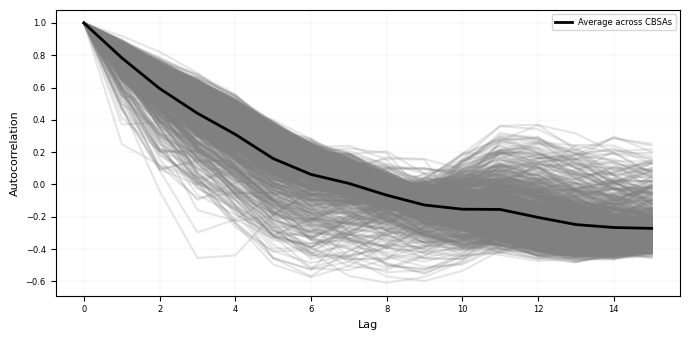

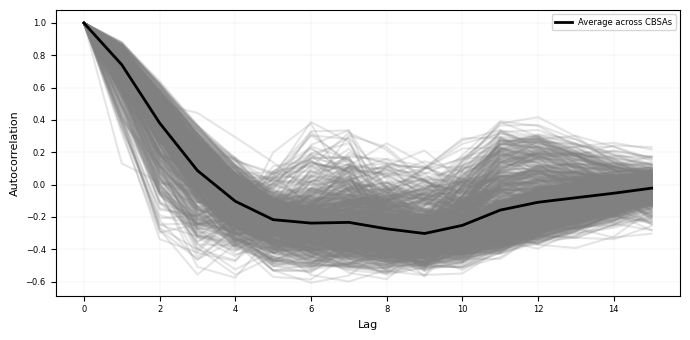

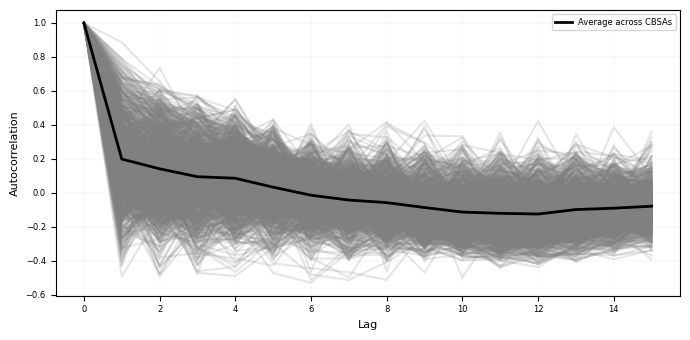

In [ ]:
# LATEX CODE
# Target variables
target_cols = ['per_cap_income_adj', 'unemployment', 'Job_creation_entries']
max_lag = 15

for col in target_cols:
    fig, ax = plt.subplots(figsize=(7, 3.5))  # LaTeX two-column size

    # Collect ACF values per CBSA
    acf_list = []
    for cbsa, group in cbsa_agg.groupby("CBSA_Code"):
        series = group[col].dropna()
        if len(series) > 1:
            try:
                acf_vals = acf(series, nlags=max_lag, fft=True)
                acf_list.append(acf_vals)
                # plot each CBSA faintly
                ax.plot(range(len(acf_vals)), acf_vals, alpha=0.2, color="gray")
            except Exception:
                continue

    # Plot average across CBSAs
    if acf_list:
        acf_array = np.vstack(acf_list)
        acf_mean = np.nanmean(acf_array, axis=0)
        ax.plot(range(len(acf_mean)), acf_mean, color="black", linewidth=2, label="Average across CBSAs")
        ax.legend(fontsize=6)

    # Labels and grid
    ax.set_xlabel("Lag", fontsize=8)
    ax.set_ylabel("Autocorrelation", fontsize=8)
    ax.grid(True, alpha=0.3, linewidth=0.3)
    ax.tick_params(axis='both', labelsize=6)

    # Optional: remove title for LaTeX caption
    # ax.set_title(f"Autocorrelation of {col.replace('_',' ').title()}", fontsize=9)

    plt.tight_layout()

    # Save high-res PNG
    plt.savefig(f"acf_{col}.png", dpi=600, bbox_inches="tight")

    plt.show()


### Stationarity Checks

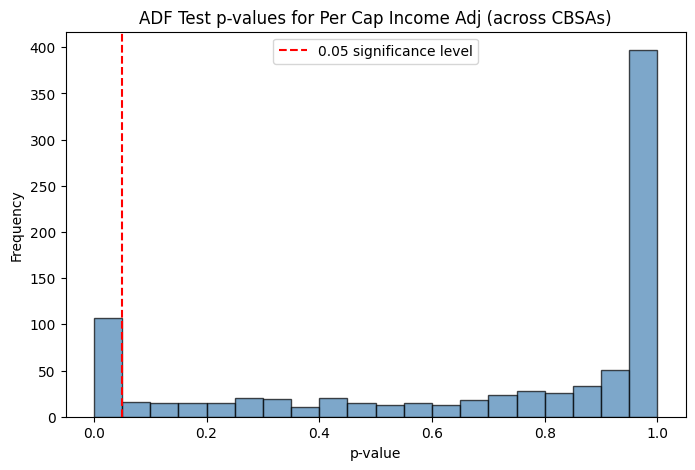

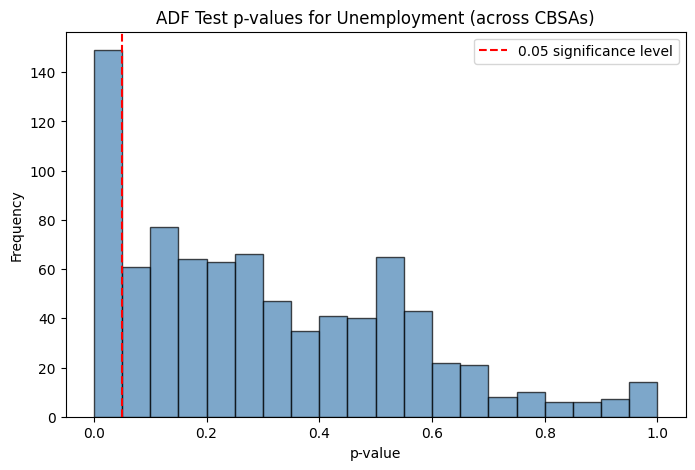

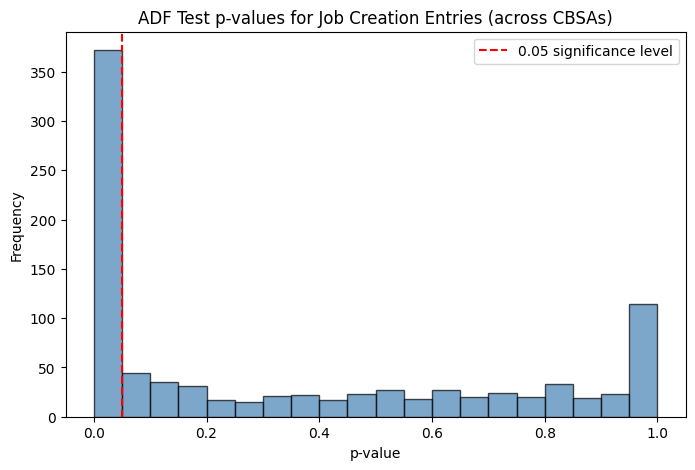

per_cap_income_adj: 12.3% of CBSAs show stationarity at 5% level
unemployment: 17.6% of CBSAs show stationarity at 5% level
Job_creation_entries: 40.3% of CBSAs show stationarity at 5% level


In [ ]:
# Apply Augmented Dickey–Fuller (ADF) test for stationarity of the targets
# Target variables
target_cols = ['per_cap_income_adj', 'unemployment', 'Job_creation_entries']

stationarity_results = {}

for col in target_cols:
    pvals = []
    for cbsa, group in cbsa_agg.groupby("CBSA_Code"):
        series = group[col].dropna()
        if len(series) > 5:  # need enough points
            try:
                result = adfuller(series, autolag='AIC')
                pvals.append(result[1])  # p-value
            except Exception:
                continue

    stationarity_results[col] = pvals

    # Plot histogram of p-values
    plt.figure(figsize=(8,5))
    plt.hist(pvals, bins=20, color="steelblue", alpha=0.7, edgecolor="black")
    plt.axvline(0.05, color="red", linestyle="--", label="0.05 significance level")
    plt.title(f"ADF Test p-values for {col.replace('_',' ').title()} (across CBSAs)")
    plt.xlabel("p-value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Summarize proportions
for col, pvals in stationarity_results.items():
    reject_ratio = np.mean(np.array(pvals) < 0.05)
    print(f"{col}: {reject_ratio:.1%} of CBSAs show stationarity at 5% level")

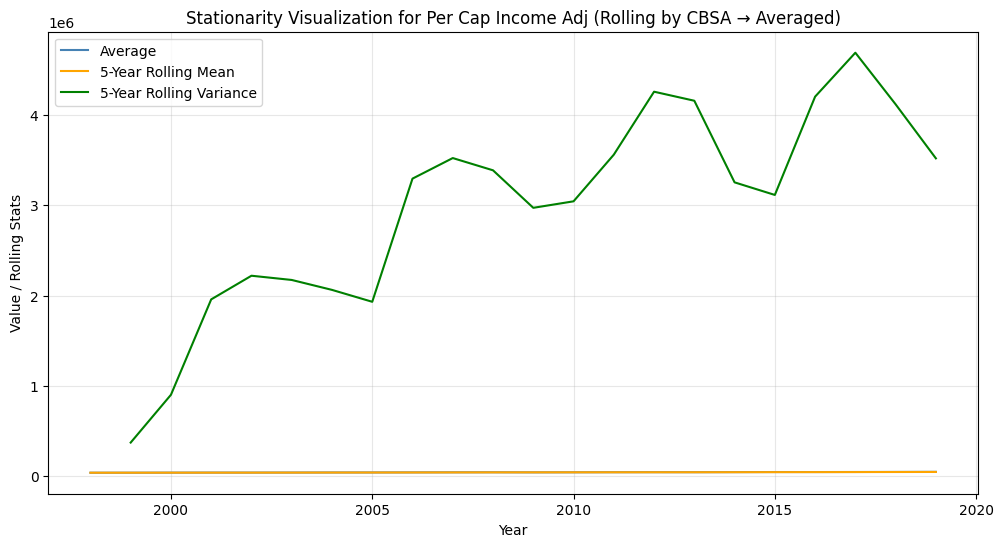

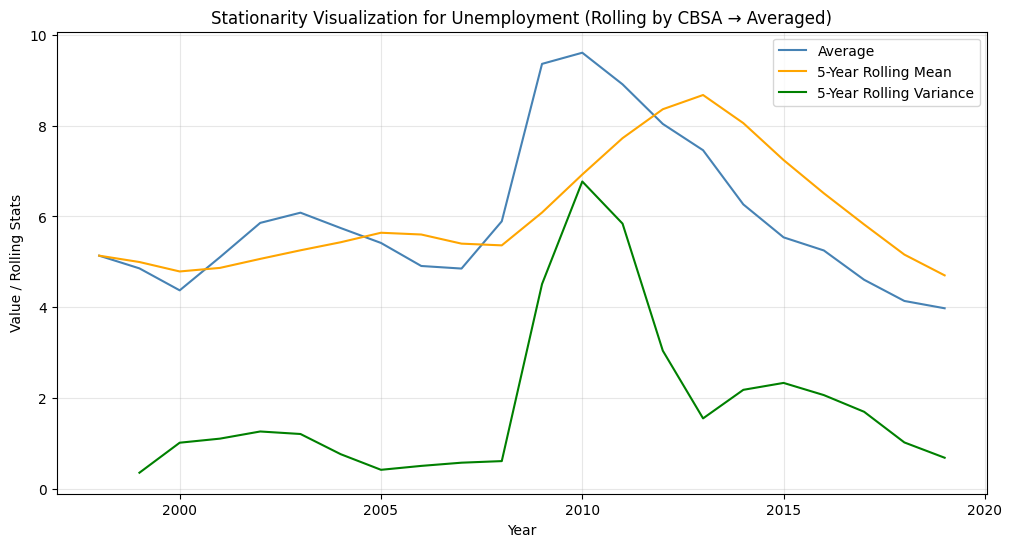

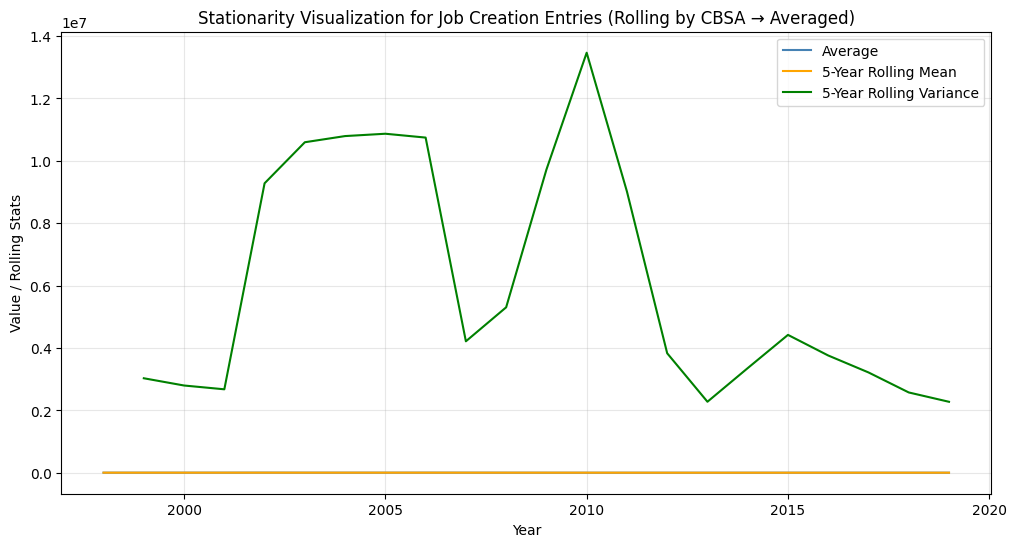

In [ ]:
# Rolling mean/variance plots to check stationarity of the targets
window = 5  # rolling window size

for col in target_cols:
    plt.figure(figsize=(12,6))

    # Compute rolling stats PER CBSA
    rolling_means = []
    rolling_vars = []
    for cbsa, group in cbsa_agg.groupby("CBSA_Code"):
        series = group[['year', col]].dropna().sort_values("year")
        if len(series) >= window:  # need enough points for rolling window
            roll_mean = series[col].rolling(window=window, min_periods=1).mean()
            roll_var  = series[col].rolling(window=window, min_periods=1).var()
            tmp = pd.DataFrame({
                "year": series["year"].values,
                "rolling_mean": roll_mean.values,
                "rolling_var": roll_var.values
            })
            rolling_means.append(tmp[["year", "rolling_mean"]])
            rolling_vars.append(tmp[["year", "rolling_var"]])

    # Concatenate across CBSAs
    rolling_means_df = pd.concat(rolling_means)
    rolling_vars_df  = pd.concat(rolling_vars)

    # Aggregate by year (average across CBSAs)
    avg_series = cbsa_agg.groupby("year")[col].mean()
    avg_rolling_mean = rolling_means_df.groupby("year")["rolling_mean"].mean()
    avg_rolling_var  = rolling_vars_df.groupby("year")["rolling_var"].mean()

    # Plot
    plt.plot(avg_series.index, avg_series.values, label="Average", color="steelblue")
    plt.plot(avg_rolling_mean.index, avg_rolling_mean.values, label=f"{window}-Year Rolling Mean", color="orange")
    plt.plot(avg_rolling_var.index, avg_rolling_var.values, label=f"{window}-Year Rolling Variance", color="green")

    plt.title(f"Stationarity Visualization for {col.replace('_',' ').title()} (Rolling by CBSA → Averaged)")
    plt.xlabel("Year")
    plt.ylabel("Value / Rolling Stats")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


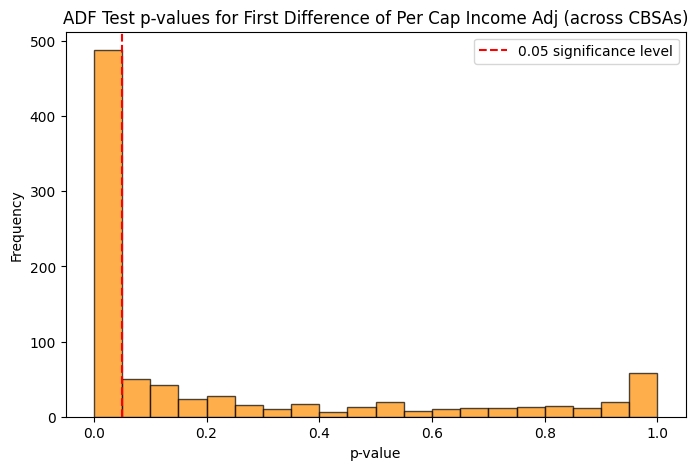

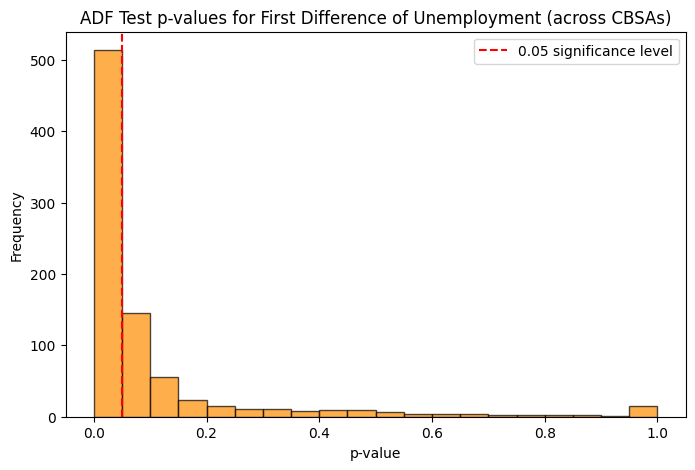

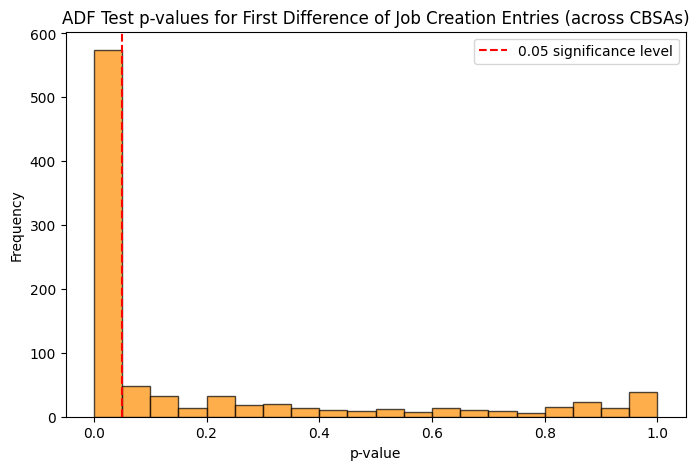

First Difference of per_cap_income_adj: 56.1% of CBSAs show stationarity at 5% level
First Difference of unemployment: 60.8% of CBSAs show stationarity at 5% level
First Difference of Job_creation_entries: 62.3% of CBSAs show stationarity at 5% level


In [ ]:
# Apply Augmented Dickey–Fuller (ADF) test for stationarity of the first differences

# Target variables
target_cols = ['per_cap_income_adj', 'unemployment', 'Job_creation_entries']

stationarity_results_diff = {}

for col in target_cols:
    pvals = []
    for cbsa, group in cbsa_agg.groupby("CBSA_Code"):
        series = group[col].dropna().sort_index()
        if len(series) > 5:  # need enough points
            # Take first difference
            diff_series = series.diff().dropna()
            if len(diff_series) > 5:  # ensure enough points remain
                try:
                    result = adfuller(diff_series, autolag='AIC')
                    pvals.append(result[1])  # p-value
                except Exception:
                    continue

    stationarity_results_diff[col] = pvals

    # Plot histogram of p-values
    plt.figure(figsize=(8,5))
    plt.hist(pvals, bins=20, color="darkorange", alpha=0.7, edgecolor="black")
    plt.axvline(0.05, color="red", linestyle="--", label="0.05 significance level")
    plt.title(f"ADF Test p-values for First Difference of {col.replace('_',' ').title()} (across CBSAs)")
    plt.xlabel("p-value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Summarize proportions
for col, pvals in stationarity_results_diff.items():
    reject_ratio = np.mean(np.array(pvals) < 0.05)
    print(f"First Difference of {col}: {reject_ratio:.1%} of CBSAs show stationarity at 5% level")


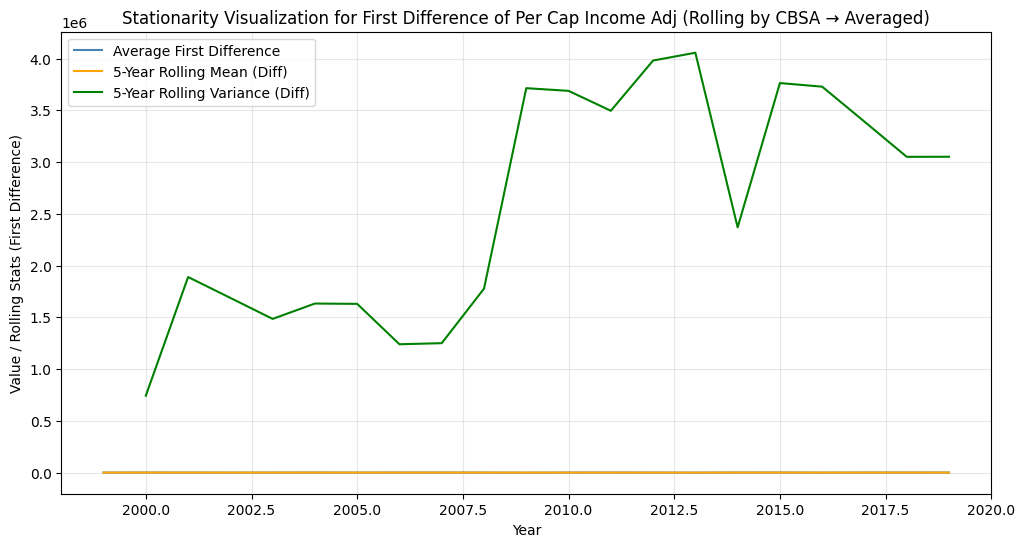

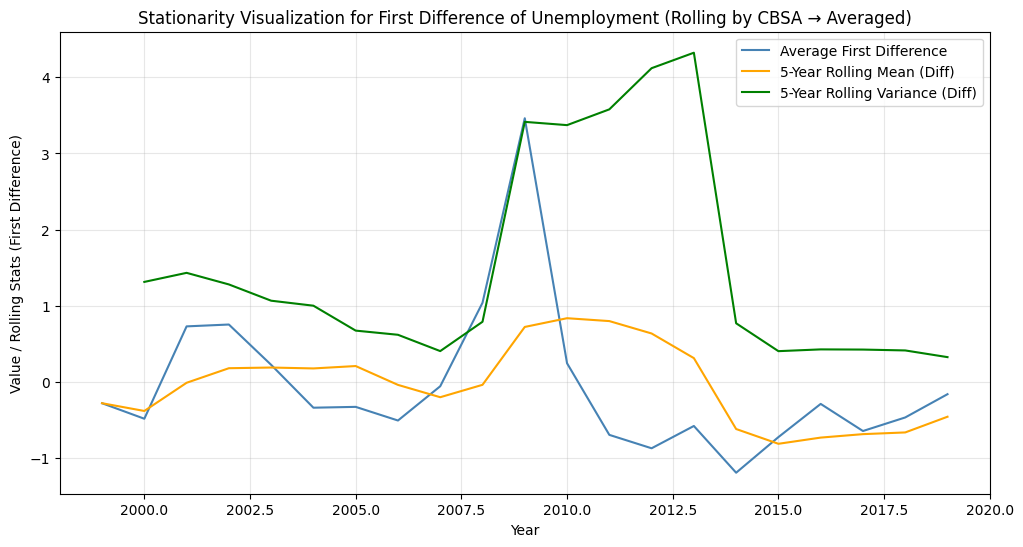

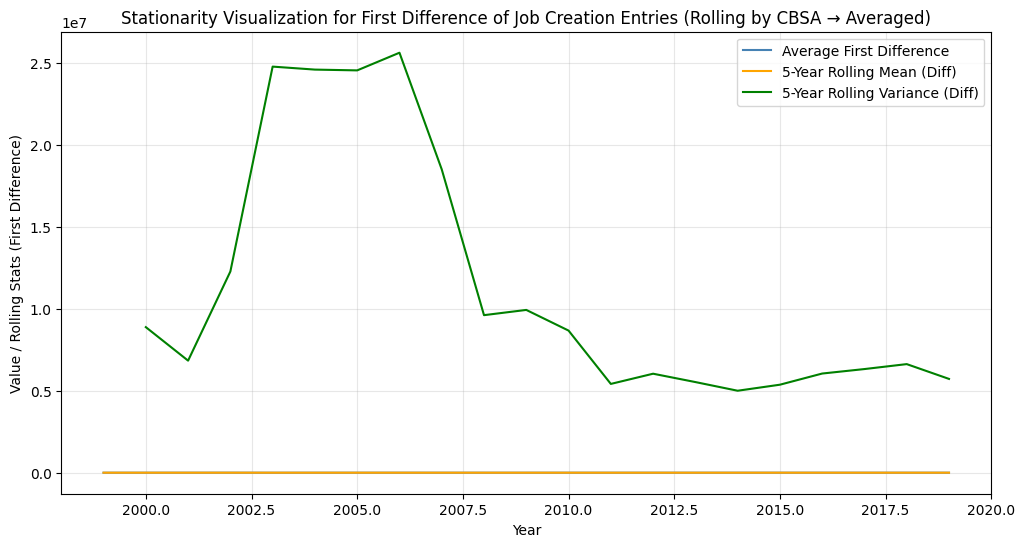

In [ ]:
# Rolling mean/variance plots for the FIRST DIFFERENCE of the targets
window = 5  # rolling window size

for col in target_cols:
    plt.figure(figsize=(12,6))

    # Compute rolling stats PER CBSA on first-differenced series
    rolling_means = []
    rolling_vars = []
    for cbsa, group in cbsa_agg.groupby("CBSA_Code"):
        series = group[['year', col]].dropna().sort_values("year")

        # Take first difference
        series[col] = series[col].diff()

        # Drop the first NA after differencing
        series = series.dropna()

        if len(series) >= window:  # need enough points
            roll_mean = series[col].rolling(window=window, min_periods=1).mean()
            roll_var  = series[col].rolling(window=window, min_periods=1).var()
            tmp = pd.DataFrame({
                "year": series["year"].values,
                "rolling_mean": roll_mean.values,
                "rolling_var": roll_var.values
            })
            rolling_means.append(tmp[["year", "rolling_mean"]])
            rolling_vars.append(tmp[["year", "rolling_var"]])

    # Concatenate across CBSAs
    rolling_means_df = pd.concat(rolling_means)
    rolling_vars_df  = pd.concat(rolling_vars)

    # Aggregate by year (average across CBSAs)
    avg_series = cbsa_agg.groupby("year")[col].mean().diff()  # overall first difference of avg
    avg_rolling_mean = rolling_means_df.groupby("year")["rolling_mean"].mean()
    avg_rolling_var  = rolling_vars_df.groupby("year")["rolling_var"].mean()

    # Plot
    plt.plot(avg_series.index, avg_series.values, label="Average First Difference", color="steelblue")
    plt.plot(avg_rolling_mean.index, avg_rolling_mean.values, label=f"{window}-Year Rolling Mean (Diff)", color="orange")
    plt.plot(avg_rolling_var.index, avg_rolling_var.values, label=f"{window}-Year Rolling Variance (Diff)", color="green")

    plt.title(f"Stationarity Visualization for First Difference of {col.replace('_',' ').title()} (Rolling by CBSA → Averaged)")
    plt.xlabel("Year")
    plt.ylabel("Value / Rolling Stats (First Difference)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### NA Checks

In [ ]:
#helper function that checks number of NA in a data frame
def na_summary(df):
    total_rows = len(df)
    summary = pd.DataFrame({
        'na_count': df.isna().sum(),
        'total_entries': total_rows,
        'na_percent': (df.isna().sum() / total_rows) * 100
    })
    return summary

In [ ]:
na_summary(cbsa_agg)

,na_count,total_entries,na_percent
CBSA_Code,0,20284,0.00
CBSA_Name,0,20284,0.00
main_state,0,20284,0.00
year,0,20284,0.00
Metro_Micro,0,20284,0.00
total_students,0,20284,0.00
diploma_recipients,7376,20284,36.36
population,1144,20284,5.64
unemployment,1696,20284,8.36
Employees,0,20284,0.00


-> The two first target columns (income and unemployment) have quite a lot of NA's. If there are too many for single CBSA we wont be able to perform reliable imputation. Below we check if the NA are systematic and remove too long NA sequences.


In [ ]:
# Load in dataset
cbsa_agg = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Final/cbsa_agg.csv')

# Export of final Data for Model Training

In [ ]:
#data frame for per cap income
excl_percap= ["total_expenditure", "diploma_recipients", "unemployment", "Job_creation_entries", "population"]
cbsa_per_cap = cbsa_agg.drop(columns=excl_percap)

#data frame for unemployment
excl_unemp = ["total_expenditure", "diploma_recipients", "per_cap_income_adj", "Job_creation_entries", "population"]
cbsa_unemp = cbsa_agg.drop(columns=excl_unemp)

#data frame for job creation
excl_jobcreat = ["total_expenditure", "diploma_recipients", "unemployment", "per_cap_income_adj", "population"]
cbsa_jobcreat = cbsa_agg.drop(columns=excl_jobcreat)

In [ ]:
#helper function that removes CBSA if they have too many NA (if there are more than 15 NA in a time series of ~25 years we wont be able to do sensible imputation )
def remove_na(df, target_col, max_na=14):
    #count NA of each CBSA
    na_counts = df.groupby("CBSA_Code")[target_col].apply(lambda x: x.isna().sum())

    #get cbsa that have less less then
    valid_cbsa = na_counts[na_counts <= max_na].index

    #return only valid cbsa
    return df[df["CBSA_Code"].isin(valid_cbsa)]

In [ ]:
#remove all CBSA that have more than 10 NA in their respecitve target variables
cbsa_per_cap = remove_na(cbsa_per_cap, "per_cap_income_adj")
cbsa_unemp = remove_na(cbsa_unemp, "unemployment")
cbsa_jobcreat = remove_na(cbsa_jobcreat, "Job_creation_entries")

In [ ]:
#check how many NA remain in the data frames using the helper function from earlier
print("Remaining NA in Per Capita Income:")
print(na_summary(cbsa_per_cap))
print("\n")
print("Remaining NA in Unemployment Rate:")
print(na_summary(cbsa_unemp))
print("\n")
print("Remaining NA in Job creation:")
print(na_summary(cbsa_jobcreat))

Remaining NA in Per Capita Income:
                       na_count  total_entries  na_percent
CBSA_Code                     0          19140        0.00
CBSA_Name                     0          19140        0.00
main_state                    0          19140        0.00
year                          0          19140        0.00
Metro_Micro                   0          19140        0.00
total_students                0          19140        0.00
Employees                     0          19140        0.00
Establishment_entries         0          19140        0.00
operations_adj                0          19140        0.00
instruction_adj               0          19140        0.00
student_adj                   0          19140        0.00
other_adj                     0          19140        0.00
per_cap_income_adj            0          19140        0.00


Remaining NA in Unemployment Rate:
                       na_count  total_entries  na_percent
CBSA_Code                     0          18

In [ ]:
#check the 2 NA rows that are still in unemp
missing_unemp = cbsa_unemp[cbsa_unemp["unemployment"].isna()][["CBSA_Name", "year","CBSA_Code"]]
print(missing_unemp)

                  CBSA_Name  year  CBSA_Code
13031  New Orleans-Metairie  2005      35380
13032  New Orleans-Metairie  2006      35380


-> Since there is only 2 NA, I looked them up manually and found the unemployment rates for New Orleans-Metairie here: https://www.huduser.gov/publications/pdf/CMARtables_NewOrleansLA.pdf

In [ ]:
#replace the NA for New Orleans manually
cbsa_unemp.loc[(cbsa_unemp["CBSA_Code"] == 35380) & (cbsa_unemp["year"] == 2005), "unemployment"] = 7.5
cbsa_unemp.loc[(cbsa_unemp["CBSA_Code"] == 35380) & (cbsa_unemp["year"] == 2006), "unemployment"] = 4.4

In [ ]:
#save datasets for further use
# cbsa_per_cap.to_csv("cbsa_per_cap.csv", index=False)
# files.download("cbsa_per_cap.csv")

# cbsa_unemp.to_csv("cbsa_unemp.csv", index=False)
# files.download("cbsa_unemp.csv")

# cbsa_jobcreat.to_csv("cbsa_jobcreat.csv", index=False)
# files.download("cbsa_jobcreat.csv")

In [ ]:
#import final datasets
cbsa_per_cap = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Final/cbsa_per_cap.csv')
cbsa_unemp = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Final/cbsa_unemp.csv')
cbsa_jobcreat = pd.read_csv('https://raw.githubusercontent.com/richardneureuther/DLSS_RNN_Project/main/Data/Final/cbsa_jobcreat.csv')